## EDA + PREPROCESS

In [78]:
#!pip install matplotlib tqdm -q
#pip install datasketch -q 


In [79]:
import os
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [80]:
pd.set_option('display.max_colwidth', None)

In [81]:
df = pd.read_csv('C:/Trendyol/new_nlp_case_final/train.csv', sep=chr(1))
test = pd.read_csv('C:/Trendyol/new_nlp_case_final/test.csv', sep=chr(1))

C:\Users\ilker\AppData\Local\Temp\ipykernel_25300\3686684637.py:2: DtypeWarning: Columns (0: product_id) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('C:/Trendyol/new_nlp_case_final/test.csv', sep=chr(1))


In [82]:
df.head()

,product_id,product_text,category
0,214477867,Lg K11 2.4a Hızlı Şarj Kablosu 2m Golden Series 18k Altın Uçlu Kırılmaz Microusb,Şarj Cihazı & Kablo
1,104723304,Müthiş Satisfyer Dual Pleasure Telefon Kontrollü Emiş Güçlü Vibratör,Vibratör
2,134486860,Sıva Altı Dekoratif 12w Modül Led 3000k(GÜNIŞIGI) Spot,Spot Lamba
3,106247966,Pc Ekmek Kutusu,Ekmek Kutusu ve Sepetleri
4,117703257,3mm Philips 55pus6262 Uyumlu Tv Ekran Koruyucu / Ekran Koruma Paneli,TV Ekran Koruyucular


In [83]:
test.head()

,product_id,product_text,category
0,206870614,Marka: 18214 Disney Princess Ahşap Puzzle 16 Parça Kategori: Spor Oyuncakları,Spor Oyuncakları
1,44839736,40507 Ortopedik Günlük Erkek Terlik,Terlik
2,36998202,Kadın Beyaz 3 Çift Pamuklu Bilek Boyu Çorap,Spor Çorap
3,6560978,Bebek Bakım Kremi 250 gr 2 Adet,Bebek Kremi ve Yağı
4,138707066,Fırsat Ayı Krom 5 Katlı Pantolon Eşarp Askısı ( 24 Adet ),Pantolon Askısı


In [84]:
print(f"Train shape: {df.shape} | Test shape: {test.shape}")

Train shape: (6855095, 3) | Test shape: (1715419, 3)


In [85]:
print(f"Train Missing Values:\n{df.isna().sum()}\n  \nTest Missing Values:\n{test.isna().sum()}")

Train Missing Values:
product_id      0
product_text    1
category        3
dtype: int64
  
Test Missing Values:
product_id      0
product_text    0
category        2
dtype: int64


In [86]:
df.loc[df['category'].isna()]

,product_id,product_text,category
5789531,218060848,Vals - 87134,NaN
5789532,87134,NaN,NaN
5789533,87134,Örgü İpi,NaN


# Duplicates

In [87]:
df["product_text_clean"] = (df["product_text"]
                            .fillna("")
                            .astype(str)
                            .str.lower()
                            .str.replace(r"[^a-zA-ZğüşöçıİĞÜŞÖÇ0-9\s]", " ", regex=True)  # Türkçe karakterleri açıkça belirt
                            .str.replace(r"\s+", " ", regex=True)
                            .str.strip())

# Duplicate incelemek için text normalizasyonu yapıyorum

In [88]:
display(df[df.duplicated(subset='product_id', keep=False)]) #Çıkarılacak
display(df[df.duplicated(subset='product_text_clean', keep=False)]) #Çıkarılacak
#df.drop_duplicates(subset='product_id', inplace=True)

,product_id,product_text,category,product_text_clean
5789532,87134,NaN,NaN,
5789533,87134,Örgü İpi,NaN,örgü ipi


,product_id,product_text,category,product_text_clean
5,79824819,Çilek Fidesi 40 Adet Yediveren Çilek Fidesi Çilek Fidanı Açık Kök Çilek Fide Albion Çilek,Fideler,çilek fidesi 40 adet yediveren çilek fidesi çilek fidanı açık kök çilek fide albion çilek
6,50996527,Kedi Tüy Bakım Kremi Kolay Taramalı - Le Charme Naturel 1000 Ml,Kedi Kuru Maması,kedi tüy bakım kremi kolay taramalı le charme naturel 1000 ml
11,126045786,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
15,219953550,Bmw Ix3 (elektrikli) 2022 Model 3d Bagaj Havuzu+3d Havuzlu Paspas,Bagaj Havuzu,bmw ix3 elektrikli 2022 model 3d bagaj havuzu 3d havuzlu paspas
18,32799685,179-180 Viva Mini Pedag Tabanlık 35-48,Tabanlık,179 180 viva mini pedag tabanlık 35 48
...,...,...,...,...
6855076,217464530,Zen Maskara,Maskara,zen maskara
6855079,176432046,Mercedes E Serisi W210 1995-2002 Deri Oto Koltuk Minderi Oturak Koruyucu Siyah Deri Kırmızı Nakış,Oto Koltuk Minderi,mercedes e serisi w210 1995 2002 deri oto koltuk minderi oturak koruyucu siyah deri kırmızı nakış
6855080,214640112,Emzıklı Kız Bebek Hedıyesı,Bebek Hediyelik,emzıklı kız bebek hedıyesı
6855082,210797455,Tunik 14531 Nfs Kolları Kopçalı,Tesettür Tunik,tunik 14531 nfs kolları kopçalı


In [89]:
df[df["product_text"] == "Cam Kesim Panosu Ortaboy (20x30cm)"] # Duplicated product_text'ler var, çıkarılacak. Aynı product_id'ye sahipler.

,product_id,product_text,category,product_text_clean
11,126045786,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
39683,109798011,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
83582,126046050,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
166803,126045971,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
417238,126166298,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
...,...,...,...,...
6496966,126046167,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
6562989,126046092,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
6715273,126045556,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm
6797073,126046111,Cam Kesim Panosu Ortaboy (20x30cm),Kesme Tahtası,cam kesim panosu ortaboy 20x30cm


In [90]:
duplicates = df[df.duplicated(subset='product_text_clean', keep=False)]
duplicates.groupby('product_text_clean').filter(lambda x: x['category'].nunique() > 1) # Duplicate product_text olup category'si farklı olanlar

,product_id,product_text,category,product_text_clean
6,50996527,Kedi Tüy Bakım Kremi Kolay Taramalı - Le Charme Naturel 1000 Ml,Kedi Kuru Maması,kedi tüy bakım kremi kolay taramalı le charme naturel 1000 ml
26,49263821,Zoo Çerez Kabı Ejderha,Beslenme&Emzirme,zoo çerez kabı ejderha
37,88831253,Satin Stocking Belt,Jartiyer,satin stocking belt
38,171181565,7016 Erkek Deri Postal Bot,Bot & Bootie,7016 erkek deri postal bot
40,199419432,Lavanta Yağı,Aktar Ürünleri,lavanta yağı
...,...,...,...,...
6855053,206457229,Dekoratif Metal Fotoğraf Makinesi Saatli Vintage Masa Saati,Masa Saati,dekoratif metal fotoğraf makinesi saatli vintage masa saati
6855065,144381694,Gümüş Parlak Kadın Şeffaf Topuklu Terlik Kaynia,Klasik Topuklu Ayakkabı,gümüş parlak kadın şeffaf topuklu terlik kaynia
6855069,199373113,Fuzzt Rat 3 Parçalı Fare Kedi Oyuncağı,Kedi Oyuncağı,fuzzt rat 3 parçalı fare kedi oyuncağı
6855082,210797455,Tunik 14531 Nfs Kolları Kopçalı,Tesettür Tunik,tunik 14531 nfs kolları kopçalı


In [91]:
display(duplicates[duplicates['product_text'] == "7016 Erkek Deri Postal Bot"])
display(duplicates[duplicates['product_text'] == "Metal Kalem Ahşap Kutulu"].head())

,product_id,product_text,category,product_text_clean
38,171181565,7016 Erkek Deri Postal Bot,Bot & Bootie,7016 erkek deri postal bot
3857809,156007657,7016 Erkek Deri Postal Bot,Çizme,7016 erkek deri postal bot


,product_id,product_text,category,product_text_clean
98164,137155711,Metal Kalem Ahşap Kutulu,Tükenmez Kalemler,metal kalem ahşap kutulu
190202,140271561,Metal Kalem Ahşap Kutulu,Tükenmez Kalemler,metal kalem ahşap kutulu
288763,205144069,Metal Kalem Ahşap Kutulu,Tükenmez Kalemler,metal kalem ahşap kutulu
296200,133300641,Metal Kalem Ahşap Kutulu,Tükenmez Kalemler,metal kalem ahşap kutulu
494311,170869864,Metal Kalem Ahşap Kutulu,Tükenmez Kalemler,metal kalem ahşap kutulu


In [92]:
# duplicate product_text'lerde farklı kategori olanların purity'leri ne?

counts = (df.groupby(["product_text_clean", "category"], sort=False)
            .size()
            .reset_index(name="cnt"))

totals = counts.groupby("product_text_clean", sort=False)["cnt"].sum().rename("total_cnt")
maxcnt = counts.groupby("product_text_clean", sort=False)["cnt"].max().rename("max_cnt")

dominant = (counts.sort_values(["product_text_clean", "cnt"], ascending=[True, False])
                  .drop_duplicates("product_text_clean")[["product_text_clean", "category"]]
                  .rename(columns={"category": "dominant_category"}))

text_stats = (dominant.merge(totals, on="product_text_clean")
                     .merge(maxcnt, on="product_text_clean"))

text_stats["purity"] = text_stats["max_cnt"] / text_stats["total_cnt"]


In [93]:
text_stats.sort_values("purity").head(20)


,product_text_clean,dominant_category,total_cnt,max_cnt,purity
860443,birlik eğitici çiftlik halısı oyuncak,Lego & Yapı Oyuncakları,15,2,0.133333
352659,6x2mm neodyum 1000 adet yuvarlak güçlü mıknatıs,Figür,12,2,0.166667
181096,25x5mm neodyum mıknatıs 100 adet yuvarlak güçlü neodyum mıknatıs,Yapıştırıcı ve Bantlar,12,2,0.166667
2458755,kadın maskeli göğüs detaylı fantezi harness suit takım,Fantezi Kostüm,28,5,0.178571
352661,6x2mm neodyum 2000 adet yuvarlak güçlü mıknatıs,Yapıştırıcı ve Bantlar,11,2,0.181818
89403,15x10x1 5mm neodyum 20 adet köşeli blok güçlü mıknatıs,"Vida, Çivi & Dübel",11,2,0.181818
1681515,flea doctor pet hayvanlar için haşere öldürücü,Köpek Oyuncağı,11,2,0.181818
89588,15x3mm neodyum 50 adet yuvarlak güçlü mıknatıs,"Vida, Çivi & Dübel",10,2,0.200000
3601678,petzoom pati desenli sevk gezdirme kayışı pzt 1128,Kedi Aksesuarı,5,1,0.200000
4637955,water dispanser sesli ve işıklı oyuncak kahve makinesi oyuncak akıds,Lego & Yapı Oyuncakları,10,2,0.200000


In [94]:
duplicates[duplicates["product_text_clean"] == "birlik eğitici çiftlik halısı oyuncak"] # Purity çok düşük, datadan çıkarılabilir.

,product_id,product_text,category,product_text_clean
1711777,174553695,Birlik Eğitici Çiftlik Halısı Oyuncak,Hayvan Figür Oyuncaklar,birlik eğitici çiftlik halısı oyuncak
1747289,174384746,Birlik Eğitici Çiftlik Halısı Oyuncak,Bebek & Aktivite Oyuncakları,birlik eğitici çiftlik halısı oyuncak
1789867,202391311,Birlik Eğitici Çiftlik Halısı Oyuncak,Eğitici Oyuncaklar,birlik eğitici çiftlik halısı oyuncak
2651314,175448684,Birlik Eğitici Çiftlik Halısı Oyuncak,Spor Oyuncakları,birlik eğitici çiftlik halısı oyuncak
3750564,197875497,Birlik Eğitici Çiftlik Halısı Oyuncak,Lego & Yapı Oyuncakları,birlik eğitici çiftlik halısı oyuncak
4057755,175365370,Birlik Eğitici Çiftlik Halısı Oyuncak,Oyuncak Bebek ve Aksesuarları,birlik eğitici çiftlik halısı oyuncak
4747971,175280696,Birlik Eğitici Çiftlik Halısı Oyuncak,Kumandalı Oyuncaklar,birlik eğitici çiftlik halısı oyuncak
4960960,175334006,Birlik Eğitici Çiftlik Halısı Oyuncak,Lego & Yapı Oyuncakları,birlik eğitici çiftlik halısı oyuncak
5299144,175288315,Birlik Eğitici Çiftlik Halısı Oyuncak,Kumandalı Oyuncaklar,birlik eğitici çiftlik halısı oyuncak
5604939,175397837,Birlik Eğitici Çiftlik Halısı Oyuncak,Oyuncak Kamyon ve İş Makineler,birlik eğitici çiftlik halısı oyuncak


In [95]:
text_stats[text_stats["purity"] < 0.7].product_text_clean.nunique()

51489

In [ ]:
text_stats[(text_stats["purity"] > 0.7) & (text_stats["purity"] < 0.8)]  # Gözle bakıldığında purity >0.7 olanlar kabul edilebilir görünüyor, geri kalanları datadan çıkartılacak.

,product_text_clean,dominant_category,total_cnt,max_cnt,purity
195,0 13 kg ana kucağı oto koltuğu mcqueen,Ana Kucağı,11,8,0.727273
196,0 13 kg ana kucağı oto koltuğu princess,Ana Kucağı,13,10,0.769231
199,0 13kg ana kucağı oto koltuğu gris,Oto Koltuğu,16,12,0.750000
833,0 33 karat pırlanta tektaş yüzük,Pırlanta Yüzük,4,3,0.750000
1367,0 5 cm 50 m gri fayans arası şerit bant,Yapıştırıcı ve Bantlar,7,5,0.714286
...,...,...,...,...,...
4953218,şort takım,Alt-Üst Takım,38,30,0.789474
4953403,şortlu saten gecelik takım lacivert,Gecelik,4,3,0.750000
4954197,şık deri jartiyer takım apft415,Fantezi Jartiyer,9,7,0.777778
4954258,şık gömlek içi lastik aksesuar apft163,Fantezi Aksesuar,8,6,0.750000


In [97]:
df2 = df.merge(text_stats[["product_text_clean", "dominant_category", "purity", "total_cnt"]],
               on="product_text_clean", how="left")
print(df2.shape)
keep_mask = (
    (df2["total_cnt"] == 1) |
    ((df2["total_cnt"] > 1) & (df2["purity"] >= 0.7) & (df2["category"] == df2["dominant_category"]))
)
df2 = df2[keep_mask].copy()

dup_mask = df2["total_cnt"] > 1
df2.loc[dup_mask, "category"] = df2.loc[dup_mask, "dominant_category"]

df2 = df2.drop_duplicates("product_text_clean", keep="first").copy()
print(df2.shape)

(6855095, 7)
(4903553, 7)


In [98]:
# exact match dışında çok yakın olanlar da çıkarılabilir.

In [99]:
# Canonicalization - 10mm ve 10 mm gibi varyasyonları tekilleştirme
# train ve test'e uyarlayıp drift incelemesi yap.

def canonicalize(df2):
    canon_df = df2.copy()
    canon_df["product_text"] = canon_df["product_text"].fillna("").astype(str)

    canon = canon_df["product_text"].str.lower()

    canon = canon.str.replace(r"[’´`'\"“”]", " ", regex=True)

    canon = (canon
            .str.replace("ı", "i")
            .str.replace("İ", "i")
            .str.replace("ş", "s").str.replace("Ş", "s")
            .str.replace("ğ", "g").str.replace("Ğ", "g")
            .str.replace("ü", "u").str.replace("Ü", "u")
            .str.replace("ö", "o").str.replace("Ö", "o")
            .str.replace("ç", "c").str.replace("Ç", "c")
    )

    canon = canon.str.replace(r"[^\w\s]", " ", regex=True)

    canon = canon.str.replace(r"\s+", " ", regex=True).str.strip()

    canon = canon.str.replace(r"\b(\d+)\s*l[uü]\b", r"\1lu", regex=True)

    canon = canon.str.replace(r"\b(\d+)\s*(adet|ad|pcs|piece|li|lu)\b", r"x\1", regex=True)

    canon = canon.str.replace(r"\bx\s*(\d+)\b", r"x\1", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*x\b", r"x\1", regex=True)
    canon = canon.str.replace(r"\b(\d+)x\b", r"x\1", regex=True)

    canon = canon.str.replace(r"\b(\d+)\s*(ml)\b", r"\1ml", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*(gr|g)\b", r"\1g", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*(kg)\b", r"\1kg", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*(lt|l)\b", r"\1l", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*(cm)\b", r"\1cm", regex=True)
    canon = canon.str.replace(r"\b(\d+)\s*(mm)\b", r"\1mm", regex=True)

    canon = canon.str.replace(r"\b(\d+)\s*-\s*(\d+)\b", r"\1_\2", regex=True)

    canon = canon.str.replace(r"\b(no|numara)\s*(\d+)\b", r"no\2", regex=True)

    canon = canon.str.replace(r"\s+", " ", regex=True).str.strip()

    canon_df["canon_text"] = canon

    return canon_df

In [100]:
canon_df = canonicalize(df2)
canon_df_test = canonicalize(test)

## TRAIN TEST DRIFT VE JUNK DATA ANALIZI

Train junk rate: 0.0005952826450534949
Test  junk rate: 0.0028593597249418363


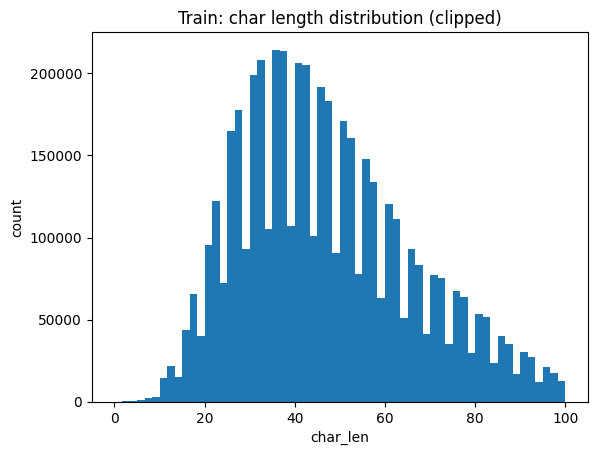

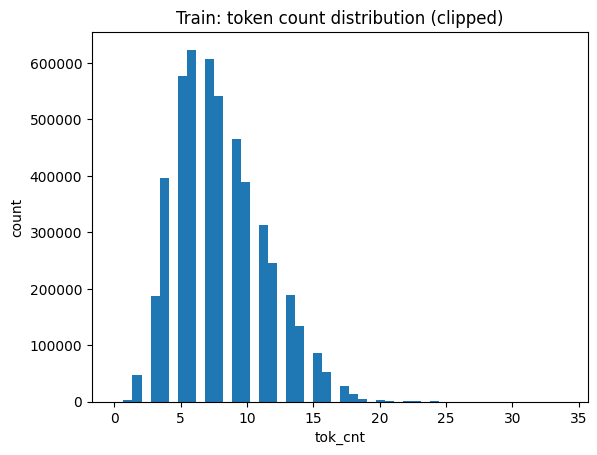


Top categories among junk (train):


category
Duvar Kağıdı                205
Saat                        191
Ampul                        63
Halı                         47
Armatür                      46
Kutu Oyunları                41
Sneaker                      41
Eğitici Oyuncaklar           38
Bot & Bootie                 37
Muzik Aleti Aksesuarları     37
Puzzle                       36
Güneş Gözlüğü                35
Sweatshirt                   28
Yüz Kremi                    25
Vücut Kremi                  25
Örgü İpi                     24
Saç Kremi                    23
Terlik                       23
İç Mekan Bitkileri           21
T-Shirt                      21
dtype: int64

In [101]:
import matplotlib.pyplot as plt


canon_df["product_text"] = canon_df["product_text"].fillna("").astype(str)
canon_df_test["product_text"] = canon_df_test["product_text"].fillna("").astype(str)

def light_clean(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str).str.lower()
    s = s.str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

canon_df["text_for_model"] = light_clean(canon_df["product_text"])
canon_df_test["text_for_model"] = light_clean(canon_df_test["product_text"])

canon_df["char_len"] = canon_df["text_for_model"].str.len()
canon_df["tok_cnt"]  = canon_df["text_for_model"].str.split().str.len()

canon_df_test["char_len"] = canon_df_test["text_for_model"].str.len()
canon_df_test["tok_cnt"]  = canon_df_test["text_for_model"].str.split().str.len()

canon_df["is_junk"] = (canon_df["char_len"] < 5) | (canon_df["tok_cnt"] < 2)
canon_df_test["is_junk"] = (canon_df_test["char_len"] < 5) | (canon_df_test["tok_cnt"] < 2)

print("Train junk rate:", canon_df["is_junk"].mean())
print("Test  junk rate:", canon_df_test["is_junk"].mean())

# plots
plt.figure()
plt.hist(canon_df["char_len"].clip(0, 200), bins=60)
plt.title("Train: char length distribution (clipped)")
plt.xlabel("char_len"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(canon_df["tok_cnt"].clip(0, 50), bins=50)
plt.title("Train: token count distribution (clipped)")
plt.xlabel("tok_cnt"); plt.ylabel("count")
plt.show()

# Show top categories among junk (train)
junk_top = (canon_df[canon_df["is_junk"]]
            .groupby("category").size()
            .sort_values(ascending=False)
            .head(20))
print("\nTop categories among junk (train):")
display(junk_top)


In [102]:
canon_df = canon_df[canon_df["is_junk"] == False]
canon_df_test = canon_df_test[canon_df_test["is_junk"] == False]

In [103]:
# birebir aynı olanlar var mı test ve train arasında?
train_set = set(canon_df[canon_df["is_junk"] == False]["canon_text"].values)
test_set  = set(canon_df_test["canon_text"].values)

overlap = canon_df_test["canon_text"].isin(train_set)
print("Test'te birebir aynı olanlar:", overlap.mean(), "| count:", int(overlap.sum()))

canon_df_test.loc[overlap].groupby("category").size().sort_values(ascending=False).head(20)

Test'te birebir aynı olanlar: 0.3383895133275729 | count: 578820


category
Bagaj Havuzu                        10637
Yapışkanlı Folyo                     8105
Jant Kapağı                          8055
Oto Kokuları                         7726
Duvar Saati                          6702
Gümüş Yüzük                          6368
Spor Oyuncakları                     6318
Oto Koltuk Kılıfı                    6229
Arma Sticker & Fosfor Şeritler       5661
Sütyen                               5579
Tablet Kılıfı                        5505
Akıllı Saat Kordon                   5497
Balon                                5380
Kulak içi TWS Bluetooth Kulaklık     4584
Oto Koltuk Minderi                   4503
Rüzgarlıklar                         4421
Kulak İçi Kablolu Kulaklık           4326
Tesbih                               4295
Gümüş Bileklik                       4263
Bot & Bootie                         4223
dtype: int64

In [104]:
# Normalde train datasından çıkarılması gereken aynı product_text'leri test datasından çıkıyorum çünkü train datasında aşırı az category olmasını istemiyorum 
canon_df_test = canon_df_test[~canon_df_test["canon_text"].isin(canon_df["canon_text"].unique())]

In [105]:
canon_df[canon_df.duplicated(subset='canon_text', keep=False)]

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk
34,208027647,Transformacıon Joseph Açılıp Kapanır Silikon Çırpıcı,Çırpıcı,transformacıon joseph açılıp kapanır silikon çırpıcı,Çırpıcı,1.000000,3.0,transformacion joseph acilip kapanir silikon cirpici,transformacıon joseph açılıp kapanır silikon çırpıcı,52,6,False
136,205250138,Peluş Oturan Panda Oyuncak 30 Cm-,Peluş Oyuncaklar,peluş oturan panda oyuncak 30 cm,Peluş Oyuncaklar,1.000000,24.0,pelus oturan panda oyuncak 30cm,peluş oturan panda oyuncak 30 cm,32,6,False
169,37889116,Dis Dikiz Aynasi Elektrikli Katlanir Isitmali Astarli Sinyalli Sol Auris 13-,Dikiz Aynası,dis dikiz aynasi elektrikli katlanir isitmali astarli sinyalli sol auris 13,Dikiz Aynası,1.000000,2.0,dis dikiz aynasi elektrikli katlanir isitmali astarli sinyalli sol auris 13,dis dikiz aynasi elektrikli katlanir isitmali astarli sinyalli sol auris 13,75,11,False
338,189629901,Kız Çocuk Eşofman Takımı,Alt-Üst Takım,kız çocuk eşofman takımı,Alt-Üst Takım,0.989011,91.0,kiz cocuk esofman takimi,kız çocuk eşofman takımı,24,4,False
364,82500179,Erkek Gömlek,Gömlek,erkek gömlek,Gömlek,0.996815,314.0,erkek gomlek,erkek gömlek,12,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6853955,36903354,Kadın Sim Detayli Tayt,Tayt,kadın sim detayli tayt,Tayt,1.000000,1.0,kadin sim detayli tayt,kadın sim detayli tayt,22,4,False
6854123,102599659,I Love My Seat Logo Yazısı Araç Sticker 100 Cm - Beyaz,Arma Sticker & Fosfor Şeritler,i love my seat logo yazısı araç sticker 100 cm beyaz,Arma Sticker & Fosfor Şeritler,1.000000,1.0,i love my seat logo yazisi arac sticker 100cm beyaz,i love my seat logo yazısı araç sticker 100 cm beyaz,52,11,False
6854176,148376337,Tunik Sweat,Sweatshirt,tunik sweat,Sweatshirt,1.000000,1.0,tunik sweat,tunik sweat,11,2,False
6854336,102360968,Kobra Yılanı Hayvanı Sticker Yapıştırması Araç Ve Duvar Için 100cm - Yeşil,Arma Sticker & Fosfor Şeritler,kobra yılanı hayvanı sticker yapıştırması araç ve duvar için 100cm yeşil,Arma Sticker & Fosfor Şeritler,1.000000,1.0,kobra yilani hayvani sticker yapistirmasi arac ve duvar icin 100cm yesil,kobra yılanı hayvanı sticker yapıştırması araç ve duvar için 100cm yeşil,72,11,False


In [106]:
canon_df[canon_df["canon_text"] == "kristal kadeh 350ml"]

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk
417,150567935,Kristal Kadeh 350 ml,Kadeh,kristal kadeh 350 ml,Kadeh,1.0,2.0,kristal kadeh 350ml,kristal kadeh 350 ml,20,4,False
193621,150568685,Kristal Kadeh 350ml,Kadeh,kristal kadeh 350ml,Kadeh,1.0,2.0,kristal kadeh 350ml,kristal kadeh 350ml,19,3,False


In [107]:
canon_df.drop_duplicates("canon_text", keep="first", inplace=True)
canon_df_test.drop_duplicates("canon_text", keep="first", inplace=True)

JS divergence(category dist): 0.002783070388988107


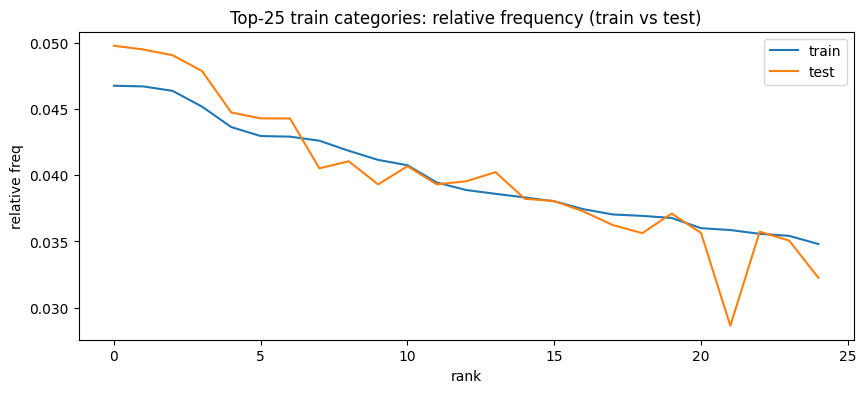

In [31]:
import numpy as np

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5*(p+q)
    return 0.5*np.sum(p*np.log(p/m)) + 0.5*np.sum(q*np.log(q/m))

train_cat = canon_df["category"].value_counts()
test_cat  = canon_df_test["category"].value_counts()

cats = train_cat.index.union(test_cat.index)
p = train_cat.reindex(cats, fill_value=0).values
q = test_cat.reindex(cats, fill_value=0).values

print("JS divergence(category dist):", js_divergence(p, q))

top25 = train_cat.head(25).index
plot_df = pd.DataFrame({
    "train": train_cat.reindex(top25).fillna(0),
    "test":  test_cat.reindex(top25).fillna(0),
})
plot_df = plot_df / plot_df.sum()

plt.figure(figsize=(10,4))
plt.plot(plot_df["train"].values, label="train")
plt.plot(plot_df["test"].values, label="test")
plt.title("Top-25 train categories: relative frequency (train vs test)")
plt.xlabel("rank"); plt.ylabel("relative freq")
plt.legend()
plt.show()


In [32]:
plot_df["diff"] = plot_df["train"] - plot_df["test"]
plot_df.sort_values("diff").sort_values("diff").head(20)

,train,test,diff
category,,,
Oto Boya,0.046756,0.049777,-0.003020
Oto Paspasları,0.046706,0.049494,-0.002788
Oto Branda,0.046368,0.049059,-0.002691
Yazıcı Sarf Malzemeleri,0.045183,0.047871,-0.002689
Güneş Gözlüğü,0.038595,0.040231,-0.001636
Bardak Altlığı,0.042912,0.044284,-0.001371
Kupalar,0.042960,0.044294,-0.001334
Rozet,0.043632,0.044738,-0.001106
Saat,0.038884,0.039543,-0.000659


In [33]:
top25 = canon_df["category"].value_counts().head(25).index
train_rel = (canon_df["category"].value_counts().reindex(top25, fill_value=0) / len(canon_df))
test_rel  = (canon_df_test["category"].value_counts().reindex(top25, fill_value=0) / len(canon_df_test))

delta = (test_rel - train_rel).sort_values()
display(pd.DataFrame({"train_rel": train_rel, "test_rel": test_rel, "delta": test_rel-train_rel})
        .loc[top25]
        .sort_values("delta"))


,train_rel,test_rel,delta
category,,,
Kulak İçi Kablolu Kulaklık,0.006229,0.005008,-0.001221
Gömlek,0.006045,0.005640,-0.000405
Bot & Bootie,0.007400,0.007085,-0.000315
Motosiklet Branda,0.007148,0.006873,-0.000275
Kapak & Kılıf,0.006414,0.006230,-0.000184
Direksiyon Ürünleri,0.006433,0.006336,-0.000097
"Kartuş, Toner & Drum",0.007268,0.007179,-0.000089
Omuz Çantası,0.006253,0.006232,-0.000020
T-Shirt,0.006152,0.006132,-0.000020


KS test (char_len) stat: 0.0021813845674545362 p-value: 0.000319404555452179


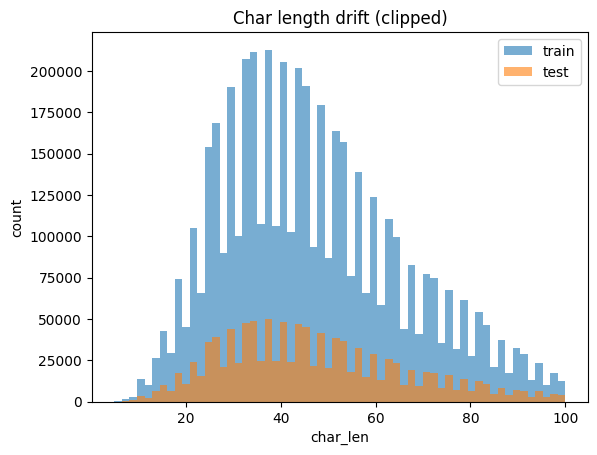

In [34]:
from scipy.stats import ks_2samp

# Use text_for_model lengths
train_len = canon_df["char_len"].values
test_len  = canon_df_test["char_len"].values

stat, pval = ks_2samp(train_len, test_len)
print("KS test (char_len) stat:", stat, "p-value:", pval)

plt.figure()
plt.hist(train_len.clip(0,200), bins=60, alpha=0.6, label="train")
plt.hist(test_len.clip(0,200), bins=60, alpha=0.6, label="test")
plt.title("Char length drift (clipped)")
plt.xlabel("char_len"); plt.ylabel("count")
plt.legend()
plt.show()


In [35]:
from collections import Counter

# Tüm kelimeleri topla ve say
tum_kelimeler = canon_df['canon_text'].str.lower().str.split().explode()
Counter(tum_kelimeler).most_common(100)

[('kadin', 516834),
 ('siyah', 452376),
 ('uyumlu', 335720),
 ('erkek', 288480),
 ('ve', 243129),
 ('seti', 220715),
 ('beyaz', 219107),
 ('1', 165189),
 ('deri', 164506),
 ('3', 157538),
 ('desenli', 151505),
 ('mavi', 151494),
 ('gri', 129457),
 ('2', 129210),
 ('gumus', 128305),
 ('takimi', 121078),
 ('takim', 119860),
 ('kirmizi', 118343),
 ('renk', 117949),
 ('sarj', 112065),
 ('x2', 111868),
 ('oto', 111359),
 ('model', 102928),
 ('duvar', 96707),
 ('set', 95556),
 ('tasli', 94053),
 ('ayakkabi', 91822),
 ('arac', 91151),
 ('kilifi', 89692),
 ('4', 89572),
 ('cm', 89477),
 ('bebek', 87708),
 ('5', 87344),
 ('x3', 86895),
 ('sari', 84535),
 ('kol', 84501),
 ('kolye', 83177),
 ('el', 82978),
 ('pembe', 82229),
 ('yesil', 80867),
 ('altin', 80379),
 ('desen', 80097),
 ('ici', 77858),
 ('ahsap', 77585),
 ('kupe', 76314),
 ('cift', 75153),
 ('baskili', 73574),
 ('yaka', 73480),
 ('metal', 72694),
 ('boya', 72533),
 ('detayli', 71845),
 ('x4', 70727),
 ('on', 70548),
 ('telefon', 70192

In [36]:
# birbirine benzeyen çok fazla ürün var.
canon_df[canon_df['canon_text'].str.contains('uyumlu')].sort_values('canon_text').head(20)

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk
2819442,196523864,0.25 mm Iphone 11 Pro Max Xs Max Uyumlu 3d Curved Full Kaplama Kırılmaz Cam Ekran Koruyucu,Ekran Koruyucu Film,0 25 mm iphone 11 pro max xs max uyumlu 3d curved full kaplama kırılmaz cam ekran koruyucu,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 pro max xs max uyumlu 3d curved full kaplama kirilmaz cam ekran koruyucu,0 25 mm iphone 11 pro max xs max uyumlu 3d curved full kaplama kırılmaz cam ekran koruyucu,90,18,False
302517,86614857,0.25mm Iphone 11 Pro-xs-x 3d Curved Privacy Uyumlu Gizlili Cam Ekran Koruyucu,Ekran Koruyucu Film,0 25mm iphone 11 pro xs x 3d curved privacy uyumlu gizlili cam ekran koruyucu,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 pro xs x 3d curved privacy uyumlu gizlili cam ekran koruyucu,0 25mm iphone 11 pro xs x 3d curved privacy uyumlu gizlili cam ekran koruyucu,77,15,False
739813,127609428,0.25mm Iphone 11 Pro- Xs-x 3d Uyumlu Curved Full Kaplama Kırılmaz Cam Ekran Koruyucu,Ekran Koruyucu Film,0 25mm iphone 11 pro xs x 3d uyumlu curved full kaplama kırılmaz cam ekran koruyucu,Ekran Koruyucu Film,1.0,2.0,0 25mm iphone 11 pro xs x 3d uyumlu curved full kaplama kirilmaz cam ekran koruyucu,0 25mm iphone 11 pro xs x 3d uyumlu curved full kaplama kırılmaz cam ekran koruyucu,83,16,False
2265083,169556725,0.25 mm Iphone 11 Pro- Xs-x 3d Uyumlu Curved Full Kaplama Kırılmaz Cam Ekran Koruyucu Siyah,Ekran Koruyucu Film,0 25 mm iphone 11 pro xs x 3d uyumlu curved full kaplama kırılmaz cam ekran koruyucu siyah,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 pro xs x 3d uyumlu curved full kaplama kirilmaz cam ekran koruyucu siyah,0 25 mm iphone 11 pro xs x 3d uyumlu curved full kaplama kırılmaz cam ekran koruyucu siyah,90,18,False
504988,117696615,0.25mm Iphone 11 Pro- Xs-x Uyumlu 3d Curved Full Kaplama Kırılmaz Cam Ekran Koruyucu,Ekran Koruyucu Film,0 25mm iphone 11 pro xs x uyumlu 3d curved full kaplama kırılmaz cam ekran koruyucu,Ekran Koruyucu Film,1.0,2.0,0 25mm iphone 11 pro xs x uyumlu 3d curved full kaplama kirilmaz cam ekran koruyucu,0 25mm iphone 11 pro xs x uyumlu 3d curved full kaplama kırılmaz cam ekran koruyucu,83,16,False
6629929,149974896,"0.25mm Iphone 11 Uyumlu xr,3d Curved Full Tempered Cam Ekran Koruyucu-siyah",Ekran Koruyucu Film,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah,75,14,False
4812944,177231676,"0.25mm Iphone 11 Uyumlu -xr,3d Curved Full Tempered Cam Ekran Koruyucu-siyah-rz",Ekran Koruyucu Film,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah rz,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah rz,0 25mm iphone 11 uyumlu xr 3d curved full tempered cam ekran koruyucu siyah rz,78,15,False
4327166,196523196,0.25mm Iphone 11 Xr 3d Curved Privacy Uyumlu Gizlili Cam Ekran Koruyucu-siyah,Ekran Koruyucu Film,0 25mm iphone 11 xr 3d curved privacy uyumlu gizlili cam ekran koruyucu siyah,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 xr 3d curved privacy uyumlu gizlili cam ekran koruyucu siyah,0 25mm iphone 11 xr 3d curved privacy uyumlu gizlili cam ekran koruyucu siyah,77,14,False
3573852,175516278,"0.25 mm Iphone 11-xr,3d Uyumlu Curved Full Tempered Cam Ekran Koruyucu Siyah",Ekran Koruyucu Film,0 25 mm iphone 11 xr 3d uyumlu curved full tempered cam ekran koruyucu siyah,Ekran Koruyucu Film,1.0,1.0,0 25mm iphone 11 xr 3d uyumlu curved full tempered cam ekran koruyucu siyah,0 25 mm iphone 11 xr 3d uyumlu curved full tempered cam ekran koruyucu siyah,76,15,False
2411324,149283437,0.25mm Iphone 11-xr Uyumlu 3d Curved Full Anti Blue Ekran Koruyucu-siyah,Ekran Koruyucu Film,0 25mm iphone 11 xr uyumlu 3d curved full anti blue ekran koruyucu siyah,Ekran Koruyucu Film,

In [37]:
canon_df[canon_df['canon_text'].str.contains('desenli')].sort_values('canon_text').head(20)

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk
2244254,51378377,0.2373.e1 My First Yunus Desenli Çakı ve Boyama Kitabı,Çakı & Bıçak Aksesuarları,0 2373 e1 my first yunus desenli çakı ve boyama kitabı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 2373 e1 my first yunus desenli caki ve boyama kitabi,0 2373 e1 my first yunus desenli çakı ve boyama kitabı,54,11,False
2687770,48803397,0 - 6 Aylık 2'li Klasik Desenli Silikon Emzik - Renkli,Emzik,0 6 aylık 2 li klasik desenli silikon emzik renkli,Emzik,1.0,2.0,0 6 aylik x2 klasik desenli silikon emzik renkli,0 6 aylık 2 li klasik desenli silikon emzik renkli,50,10,False
2176400,6008717,? 0.6223.l1807 Classic Mexican Sunset Desenli 2018 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l1807 classic mexican sunset desenli 2018 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l1807 classic mexican sunset desenli 2018 limitli caki,0 6223 l1807 classic mexican sunset desenli 2018 limitli çakı,61,10,False
1619026,123187754,0.6223.l1903 Classic Mexican Tacos Desenli 2019 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l1903 classic mexican tacos desenli 2019 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,2.0,0 6223 l1903 classic mexican tacos desenli 2019 limitli caki,0 6223 l1903 classic mexican tacos desenli 2019 limitli çakı,60,10,False
4887844,32361283,0.6223.l1907 Classic Swiss Mountain Dinner Desenli 2019 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l1907 classic swiss mountain dinner desenli 2019 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l1907 classic swiss mountain dinner desenli 2019 limitli caki,0 6223 l1907 classic swiss mountain dinner desenli 2019 limitli çakı,68,11,False
3604494,42130321,0.6223.l2001 Classic Bike Ride Desenli 2020 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l2001 classic bike ride desenli 2020 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l2001 classic bike ride desenli 2020 limitli caki,0 6223 l2001 classic bike ride desenli 2020 limitli çakı,56,10,False
6128867,42382856,0.6223.l2002 Classic I Love Hiking Desenli 2020 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l2002 classic i love hiking desenli 2020 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l2002 classic i love hiking desenli 2020 limitli caki,0 6223 l2002 classic i love hiking desenli 2020 limitli çakı,60,11,False
6526351,42382924,?? 0.6223.l2004 Classic Climb High Desenli 2020 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l2004 classic climb high desenli 2020 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l2004 classic climb high desenli 2020 limitli caki,0 6223 l2004 classic climb high desenli 2020 limitli çakı,57,10,False
3955761,42382911,??? 0.6223.l2006 Classic Deep Dive Desenli 2020 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l2006 classic deep dive desenli 2020 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l2006 classic deep dive desenli 2020 limitli caki,0 6223 l2006 classic deep dive desenli 2020 limitli çakı,56,10,False
2908497,42385303,???? 0.6223.l2007 Classic World Of Soccer Desenli 2020 Limitli Çakı,Çakı & Bıçak Aksesuarları,0 6223 l2007 classic world of soccer desenli 2020 limitli çakı,Çakı & Bıçak Aksesuarları,1.0,1.0,0 6223 l2007 classic world of soccer desenli 2020 limitli caki,0 6223 l2007 classic world of soccer desenli 2020 limitli çakı,62,11,False


In [38]:

# LSH ile yüksek oranda aynı n-gram'lara sahip sample'ları bulmak lazım.

from datasketch import MinHash, MinHashLSH, LeanMinHash
from tqdm.auto import tqdm


In [39]:

# Work on canon_text (dedupe text). Filter tiny ones.
work = canon_df[["canon_text","category"]].copy()
work["canon_text"] = work["canon_text"].fillna("").astype(str)
work = work[work["canon_text"].str.len() >= 8].reset_index(drop=True)

texts = work["canon_text"].tolist()
n = len(texts)

# bucket by first two tokens to avoid candidate explosion
m = work["canon_text"].str.extract(r'^\s*([^\s]+)\s*([^\s]*)')
block = (m[0].fillna("") + " " + m[1].fillna("")).str.strip()
N_BUCKETS = 512
work["bucket"] = (pd.util.hash_pandas_object(block, index=False).astype("uint64") % N_BUCKETS).astype("uint16")


In [40]:
class UnionFind:
    def __init__(self, n):
        self.parent = np.arange(n, dtype=np.int32)
        self.rank = np.zeros(n, dtype=np.int8)
    def find(self, x):
        p = self.parent
        while p[x] != x:
            p[x] = p[p[x]]
            x = p[x]
        return x
    def union(self, a, b):
        pa, pb = self.find(a), self.find(b)
        if pa == pb: return
        ra, rb = self.rank[pa], self.rank[pb]
        if ra < rb:
            self.parent[pa] = pb
        elif ra > rb:
            self.parent[pb] = pa
        else:
            self.parent[pb] = pa
            self.rank[pa] += 1

def token_ngrams_set(t, n=2):
    toks = t.split()
    if len(toks) < n:
        return None
    return {"_".join(toks[i:i+n]) for i in range(len(toks)-n+1)}


In [41]:

# Noise grouping params (looser)
THRESH = 0.62
NUM_PERM = 64
NGRAM = 2

uf = UnionFind(n)
bucket_groups = work.groupby("bucket").indices

for b, idx in tqdm(bucket_groups.items(), total=len(bucket_groups), desc="Noise-grouping LSH"):
    if len(idx) < 2:
        continue

    lsh = MinHashLSH(threshold=THRESH, num_perm=NUM_PERM)

    for i in idx:
        grams = token_ngrams_set(texts[i], n=NGRAM)
        if not grams:
            continue

        mh = MinHash(num_perm=NUM_PERM)
        mh.update_batch([g.encode("utf-8") for g in grams])
        lmh = LeanMinHash(mh)

        cands = lsh.query(lmh)
        for j in cands:
            uf.union(i, int(j))

        lsh.insert(i, lmh)

roots = np.array([uf.find(i) for i in range(n)], dtype=np.int32)
cluster_id, _ = pd.factorize(roots)
work["cluster_id_noise"] = cluster_id.astype(np.int32)

print("Noise clusters:", work["cluster_id_noise"].nunique())
work.head()

Noise-grouping LSH: 100%|██████████| 512/512 [59:58<00:00,  7.03s/it]  


Noise clusters: 3616035


,canon_text,category,bucket,cluster_id_noise
0,lg k11 2 4a hizli sarj kablosu 2m golden series 18k altin uclu kirilmaz microusb,Şarj Cihazı & Kablo,97,0
1,muthis satisfyer dual pleasure telefon kontrollu emis guclu vibrator,Vibratör,169,1
2,siva alti dekoratif 12w modul led 3000k gunisigi spot,Spot Lamba,371,2
3,pc ekmek kutusu,Ekmek Kutusu ve Sepetleri,133,3
4,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,TV Ekran Koruyucular,25,4


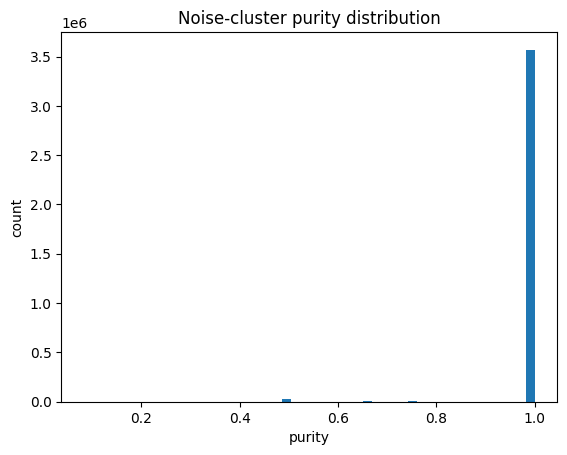

count    3.616035e+06
mean     9.943151e-01
std      5.186859e-02
min      8.333333e-02
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: purity, dtype: float64


,cluster_id_noise,total_cnt,max_cnt,dominant_category,dominant_cnt,purity
95240,95240,36,3,Bluz,3,0.083333
82476,82476,69,6,Mayo,6,0.086957
280589,280589,21,2,Spor T-Shirt,2,0.095238
59989,59989,94,9,Bijuteri Küpe,9,0.095745
455719,455719,10,1,Bluz,1,0.100000
1484684,1484684,10,1,Body,1,0.100000
54140,54140,38,4,Sandalet,4,0.105263
111635,111635,19,2,Abiye & Mezuniyet Elbisesi,2,0.105263
801,801,2503,270,Casual Ayakkabı,270,0.107871
224838,224838,37,4,Tesettür Elbise,4,0.108108


In [42]:
cl = (work.groupby(["cluster_id_noise","category"]).size().reset_index(name="cnt"))
cl_stats = (cl.groupby("cluster_id_noise")["cnt"].agg(["sum","max"])
            .rename(columns={"sum":"total_cnt","max":"max_cnt"}).reset_index())
cl_dom = cl.sort_values(["cluster_id_noise","cnt"], ascending=[True, False]).drop_duplicates("cluster_id_noise")
cl_dom = cl_dom.rename(columns={"category":"dominant_category","cnt":"dominant_cnt"})[["cluster_id_noise","dominant_category","dominant_cnt"]]

cl_pur = cl_stats.merge(cl_dom, on="cluster_id_noise", how="left")
cl_pur["purity"] = cl_pur["max_cnt"] / cl_pur["total_cnt"]

plt.figure()
plt.hist(cl_pur["purity"].values, bins=50)
plt.title("Noise-cluster purity distribution")
plt.xlabel("purity"); plt.ylabel("count")
plt.show()

print(cl_pur["purity"].describe())

# show biggest low-purity clusters (these are your "noisy label zones")
display(cl_pur.sort_values(["purity","total_cnt"], ascending=[True, False]).head(15))


In [43]:
# roots -> factorized cluster ids
roots = np.array([uf.find(i) for i in range(n)], dtype=np.int32)
cluster_id, _ = pd.factorize(roots)

work["cluster_id"] = cluster_id.astype(np.int32)

print("Number of clusters:", work["cluster_id"].nunique())
work.head()


Number of clusters: 3616035


,canon_text,category,bucket,cluster_id_noise,cluster_id
0,lg k11 2 4a hizli sarj kablosu 2m golden series 18k altin uclu kirilmaz microusb,Şarj Cihazı & Kablo,97,0,0
1,muthis satisfyer dual pleasure telefon kontrollu emis guclu vibrator,Vibratör,169,1,1
2,siva alti dekoratif 12w modul led 3000k gunisigi spot,Spot Lamba,371,2,2
3,pc ekmek kutusu,Ekmek Kutusu ve Sepetleri,133,3,3
4,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,TV Ekran Koruyucular,25,4,4


In [44]:
canon_df

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk
0,214477867,Lg K11 2.4a Hızlı Şarj Kablosu 2m Golden Series 18k Altın Uçlu Kırılmaz Microusb,Şarj Cihazı & Kablo,lg k11 2 4a hızlı şarj kablosu 2m golden series 18k altın uçlu kırılmaz microusb,Şarj Cihazı & Kablo,1.0,1.0,lg k11 2 4a hizli sarj kablosu 2m golden series 18k altin uclu kirilmaz microusb,lg k11 2 4a hızlı şarj kablosu 2m golden series 18k altın uçlu kırılmaz microusb,80,15,False
1,104723304,Müthiş Satisfyer Dual Pleasure Telefon Kontrollü Emiş Güçlü Vibratör,Vibratör,müthiş satisfyer dual pleasure telefon kontrollü emiş güçlü vibratör,Vibratör,1.0,1.0,muthis satisfyer dual pleasure telefon kontrollu emis guclu vibrator,müthiş satisfyer dual pleasure telefon kontrollü emiş güçlü vibratör,68,9,False
2,134486860,Sıva Altı Dekoratif 12w Modül Led 3000k(GÜNIŞIGI) Spot,Spot Lamba,sıva altı dekoratif 12w modül led 3000k günişigi spot,Spot Lamba,1.0,1.0,siva alti dekoratif 12w modul led 3000k gunisigi spot,sıva altı dekoratif 12w modül led 3000k günişigi spot,53,9,False
3,106247966,Pc Ekmek Kutusu,Ekmek Kutusu ve Sepetleri,pc ekmek kutusu,Ekmek Kutusu ve Sepetleri,1.0,1.0,pc ekmek kutusu,pc ekmek kutusu,15,3,False
4,117703257,3mm Philips 55pus6262 Uyumlu Tv Ekran Koruyucu / Ekran Koruma Paneli,TV Ekran Koruyucular,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,TV Ekran Koruyucular,1.0,1.0,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,66,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6855089,142496167,265/40zr20 104y Xl Acoustic M01 Pilot Sport 4s (YAZ) (2021),Lastik,265 40zr20 104y xl acoustic m01 pilot sport 4s yaz 2021,Lastik,1.0,1.0,265 40zr20 104y xl acoustic m01 pilot sport 4s yaz 2021,265 40zr20 104y xl acoustic m01 pilot sport 4s yaz 2021,55,11,False
6855090,213018596,Pure Oje: 609 Kategori: Oje,Oje,pure oje 609 kategori oje,Oje,1.0,1.0,pure oje 609 kategori oje,pure oje 609 kategori oje,25,5,False
6855091,205963428,"Dekoratif Çok Amaçlı Mermer Kenarlıklı Tepsi Beyaz; Banyo, Mutfak, Kahve Sunumları",Tepsi,dekoratif çok amaçlı mermer kenarlıklı tepsi beyaz banyo mutfak kahve sunumları,Tepsi,1.0,1.0,dekoratif cok amacli mermer kenarlikli tepsi beyaz banyo mutfak kahve sunumlari,dekoratif çok amaçlı mermer kenarlıklı tepsi beyaz banyo mutfak kahve sunumları,79,11,False
6855092,58894024,281 Et Ve Köfte Tutucu Izgara Mangal 63cm Krom Kırmızı,Mangal Aksesuarları,281 et ve köfte tutucu izgara mangal 63cm krom kırmızı,Mangal Aksesuarları,1.0,1.0,281 et ve kofte tutucu izgara mangal 63cm krom kirmizi,281 et ve köfte tutucu izgara mangal 63cm krom kırmızı,54,10,False


In [45]:
LSH_df = canon_df.copy()
LSH_df["canon_text"] = LSH_df["canon_text"].fillna("").astype(str)

LSH_df = LSH_df.merge(work[["canon_text", "cluster_id"]], on="canon_text", how="left")

# texts we filtered out (len<8) get their own singleton cluster (-1)
LSH_df["cluster_id"] = LSH_df["cluster_id"].fillna(-1).astype(np.int32)

LSH_df.head()


,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,tok_cnt,is_junk,cluster_id
0,214477867,Lg K11 2.4a Hızlı Şarj Kablosu 2m Golden Series 18k Altın Uçlu Kırılmaz Microusb,Şarj Cihazı & Kablo,lg k11 2 4a hızlı şarj kablosu 2m golden series 18k altın uçlu kırılmaz microusb,Şarj Cihazı & Kablo,1.0,1.0,lg k11 2 4a hizli sarj kablosu 2m golden series 18k altin uclu kirilmaz microusb,lg k11 2 4a hızlı şarj kablosu 2m golden series 18k altın uçlu kırılmaz microusb,80,15,False,0
1,104723304,Müthiş Satisfyer Dual Pleasure Telefon Kontrollü Emiş Güçlü Vibratör,Vibratör,müthiş satisfyer dual pleasure telefon kontrollü emiş güçlü vibratör,Vibratör,1.0,1.0,muthis satisfyer dual pleasure telefon kontrollu emis guclu vibrator,müthiş satisfyer dual pleasure telefon kontrollü emiş güçlü vibratör,68,9,False,1
2,134486860,Sıva Altı Dekoratif 12w Modül Led 3000k(GÜNIŞIGI) Spot,Spot Lamba,sıva altı dekoratif 12w modül led 3000k günişigi spot,Spot Lamba,1.0,1.0,siva alti dekoratif 12w modul led 3000k gunisigi spot,sıva altı dekoratif 12w modül led 3000k günişigi spot,53,9,False,2
3,106247966,Pc Ekmek Kutusu,Ekmek Kutusu ve Sepetleri,pc ekmek kutusu,Ekmek Kutusu ve Sepetleri,1.0,1.0,pc ekmek kutusu,pc ekmek kutusu,15,3,False,3
4,117703257,3mm Philips 55pus6262 Uyumlu Tv Ekran Koruyucu / Ekran Koruma Paneli,TV Ekran Koruyucular,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,TV Ekran Koruyucular,1.0,1.0,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,3mm philips 55pus6262 uyumlu tv ekran koruyucu ekran koruma paneli,66,10,False,4


In [46]:
THRESH_PURITY = 0.7

# cluster size
cl_size = LSH_df.groupby("cluster_id").size().rename("cluster_size")

# label counts per cluster
lab_counts = LSH_df.groupby(["cluster_id", "category"]).size().rename("cnt").reset_index()

# dominant label count
dom = (lab_counts.sort_values(["cluster_id","cnt"], ascending=[True, False])
       .drop_duplicates("cluster_id")[["cluster_id","cnt"]]
       .rename(columns={"cnt":"dominant_cnt"}))

tot = lab_counts.groupby("cluster_id")["cnt"].sum().rename("total_cnt")

cluster_purity = dom.merge(tot, on="cluster_id").merge(cl_size, on="cluster_id")
cluster_purity["purity"] = cluster_purity["dominant_cnt"] / cluster_purity["total_cnt"]

good_clusters = set(cluster_purity.loc[cluster_purity["purity"] >= THRESH_PURITY, "cluster_id"])

LSH_df = LSH_df[LSH_df["cluster_id"].isin(good_clusters)].copy()

LSH_df["sample_weight"] = 1.0 / LSH_df["cluster_id"].map(cl_size).astype(float)

print("Before:", len(LSH_df))
print("After :", len(LSH_df))
cluster_purity["purity"].describe()


Before: 4664362
After : 4664362


count    3.616036e+06
mean     9.943149e-01
std      5.187041e-02
min      8.333333e-02
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: purity, dtype: float64

In [47]:
#!pip install openai -q  

In [48]:
LSH_df.to_csv("LSH_df_checkpoint.csv", index=False)

In [35]:
LSH_df = pd.read_csv("LSH_df_checkpoint.csv")

In [5]:
import pandas as pd
import json
from openai import OpenAI
import time
from dotenv import load_dotenv


In [50]:


# load_dotenv()

# api_key = os.getenv("OPENAI_API_KEY")
# client = OpenAI(api_key=api_key)

# unique_categories = LSH_df['category'].unique().tolist()
# print(f"Total unique categories to map: {len(unique_categories)}")

# def get_main_category_mappings(batch_categories):
#     prompt = f"""
#     You are a data labeling assistant for Trendyol, a Turkish e-commerce company.
#     I will give you a list of sub-categories (Turkish).
    
#     Task: Map each sub-category to a high-level "Main Category" (Parent Category).
    
#     Use standard e-commerce main categories like: 
#     ['Giyim', 'Ayakkabı', 'Elektronik', 'Ev & Yaşam', 'Kozmetik', 'Spor', 'Aksesuar', 'Anne & Bebek', 'Oyuncak', 'Otomotiv'].
    
#     Rules:
#     1. Be consistent. "Spor Ayakkabı" should go to "Ayakkabı", not "Spor".
#     1. BE CONSISTENT. "Oto Tampon" should go to "Otomotiv", not "Ev & Yaşam" or "Elektronik".
#     2. Return ONLY a JSON object where keys are the input categories and values are the main categories.
#     3. Do not include any markdown formatting, just the raw JSON.
    
#     Input List:
#     {batch_categories}
#     """
    
#     response = client.chat.completions.create(
#         model="gpt-4o", 
#         messages=[
#             {"role": "system", "content": "You are a helpful classification assistant that outputs JSON."},
#             {"role": "user", "content": prompt}
#         ],
#         response_format={"type": "json_object"}, 
#         temperature=0
#     )
    
#     return json.loads(response.choices[0].message.content)

# batch_size = 50
# category_mapping = {}

# print("Starting batch processing...")

# for i in range(0, len(unique_categories), batch_size):
#     batch = unique_categories[i : i + batch_size]
    
#     try:
#         batch_mapping = get_main_category_mappings(batch)
        
#         category_mapping.update(batch_mapping)
        
#         print(f"Processed batch {i // batch_size + 1}: {len(category_mapping)}/{len(unique_categories)} mapped.")
        
#         time.sleep(1) 
        
#     except Exception as e:
#         print(f"Error in batch starting at index {i}: {e}")

# LSH_df['main_category'] = LSH_df['category'].map(category_mapping).fillna('Diğer')

# print("\nMapping Complete. Sample:")
# print(LSH_df[['category', 'main_category']].drop_duplicates().head(10))

# with open('category_map.json', 'w', encoding='utf-8') as f:
#     json.dump(category_mapping, f, ensure_ascii=False, indent=4)

In [6]:
category_mapping = json.load(open('category_map.json', 'r', encoding='utf-8'))

In [7]:
taxonomy_df = pd.DataFrame(list(category_mapping.items()), 
                            columns=['Sub_Category', 'Main_Category'])


In [8]:
taxonomy_df.Main_Category.value_counts()

Main_Category
Ev & Yaşam      505
Giyim           141
Kozmetik        106
Aksesuar         89
Elektronik       82
Anne & Bebek     56
Otomotiv         53
Oyuncak          41
Spor             35
Ayakkabı         32
Name: count, dtype: int64

In [36]:
LSH_df['main_category'] = LSH_df['category'].map(category_mapping).fillna('Diğer')

In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

LSH_df = LSH_df.copy()
LSH_df = LSH_df.reset_index(drop=True)


# REQUIRED columns: main_category, category, and a text column
LABEL_COL = "category"
MAIN_COL  = "main_category"

if "text_for_model" in LSH_df.columns:
    TEXT_COL = "text_for_model"
elif "product_text" in LSH_df.columns:
    TEXT_COL = "product_text"
else:
    TEXT_COL = "canon_text"

LSH_df[TEXT_COL] = LSH_df[TEXT_COL].fillna("").astype(str)

# light clean for hashing
LSH_df["hash_text"] = (LSH_df[TEXT_COL].str.lower()
                       .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
                       .str.replace(r"\s+", " ", regex=True)
                       .str.strip())

# optional junk flag (skip junk in training)
LSH_df["tok_cnt"] = LSH_df["hash_text"].str.split().str.len()
LSH_df["char_len"] = LSH_df["hash_text"].str.len()
train_mask = (LSH_df["tok_cnt"] >= 2) & (LSH_df["char_len"] >= 5)

# IMPORTANT speed knobs:
# - unigrams only is MUCH faster than (1,2)
# - smaller hash space improves cache performance
vec = HashingVectorizer(
    n_features=2**18,       # 262k (faster than 2**20)
    alternate_sign=False,
    norm="l2",
    ngram_range=(1,1),      # unigrams only for speed
    lowercase=False
)

models = {}  # main_cat -> (clf, label_encoder)

BATCH = 50_000
EPOCHS = 1

for mc, sub_idx in tqdm(LSH_df.groupby(MAIN_COL).indices.items(), desc="Training per main_category"):
    sub_idx = np.array(list(sub_idx), dtype=np.int32)
    sub_idx = sub_idx[train_mask.values[sub_idx]]  # skip junk for training
    if len(sub_idx) == 0:
        continue

    le = LabelEncoder()
    y_mc = le.fit_transform(LSH_df.loc[sub_idx, LABEL_COL].astype(str).values)

    clf = SGDClassifier(
        loss="log_loss",
        alpha=1e-5,
        max_iter=1,
        tol=None,
        n_jobs=-1,
        random_state=42
    )

    classes_int = np.arange(len(le.classes_), dtype=np.int32)
    rng = np.random.RandomState(42)

    for ep in range(EPOCHS):
        rng.shuffle(sub_idx)
        for start in range(0, len(sub_idx), BATCH):
            idx = sub_idx[start:start+BATCH]
            Xb = vec.transform(LSH_df.loc[idx, "hash_text"])
            yb = le.transform(LSH_df.loc[idx, LABEL_COL].astype(str).values)
            if ep == 0 and start == 0:
                clf.partial_fit(Xb, yb, classes=classes_int)
            else:
                clf.partial_fit(Xb, yb)

    models[mc] = (clf, le)

print("Done. Models trained:", len(models))


Training per main_category: 100%|██████████| 10/10 [01:30<00:00,  9.02s/it]

Done. Models trained: 10


In [11]:
N = len(LSH_df)

# store results
pred_label = np.empty(N, dtype=object)
gap = np.full(N, np.nan, dtype=np.float32)        # top1_score - true_score
margin = np.full(N, np.nan, dtype=np.float32)     # top1_score - second_score
is_mismatch = np.zeros(N, dtype=bool)

SCORE_BATCH = 20_000  # larger is OK now because classes per group are smaller

for mc, sub_idx in tqdm(LSH_df.groupby(MAIN_COL).indices.items(), desc="Scoring per main_category"):
    if mc not in models:
        continue
    clf, le = models[mc]
    sub_idx = np.array(list(sub_idx), dtype=np.int32)

    # encode true labels (unknown labels in a main_cat shouldn't happen; but guard anyway)
    y_true_str = LSH_df.loc[sub_idx, LABEL_COL].astype(str).values
    known_mask = np.isin(y_true_str, le.classes_)
    idx_known = sub_idx[known_mask]
    if len(idx_known) == 0:
        continue

    y_true = le.transform(LSH_df.loc[idx_known, LABEL_COL].astype(str).values)

    for start in range(0, len(idx_known), SCORE_BATCH):
        idx = idx_known[start:start+SCORE_BATCH]
        Xb = vec.transform(LSH_df.loc[idx, "hash_text"])

        # raw scores: shape (bs, C)
        S = clf.decision_function(Xb)
        if S.ndim == 1:  # binary edge case
            S = np.vstack([-S, S]).T

        pred = S.argmax(axis=1)
        top1 = S[np.arange(len(idx)), pred]
        second = np.partition(S, -2, axis=1)[:, -2]
        m = top1 - second

        true_scores = S[np.arange(len(idx)), y_true[start:start+SCORE_BATCH]]
        g = top1 - true_scores

        is_m = (pred != y_true[start:start+SCORE_BATCH])

        pred_str = le.inverse_transform(pred)

        pred_label[idx] = pred_str
        gap[idx] = g.astype(np.float32)
        margin[idx] = m.astype(np.float32)
        is_mismatch[idx] = is_m

print("Done scoring.")
print("Mismatch rate:", float(np.nanmean(is_mismatch)))
print("Median gap:", float(np.nanmedian(gap)))


Scoring per main_category: 100%|██████████| 10/10 [03:41<00:00, 22.17s/it]

Done scoring.
Mismatch rate: 0.1273007969793082
Median gap: 0.0


In [37]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

LSH_df = LSH_df.copy()
LSH_df = LSH_df.reset_index(drop=True)

LABEL_COL = "category"
MAIN_COL  = "main_category"

# choose text column
if "text_for_model" in LSH_df.columns:
    TEXT_COL = "text_for_model"
elif "product_text" in LSH_df.columns:
    TEXT_COL = "product_text"
else:
    TEXT_COL = "canon_text"

LSH_df[TEXT_COL] = LSH_df[TEXT_COL].fillna("").astype(str)

# light clean for hashing model (keep Turkish chars)
LSH_df["hash_text"] = (LSH_df[TEXT_COL].str.lower()
                       .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
                       .str.replace(r"\s+", " ", regex=True)
                       .str.strip())

# junk flag (don’t train/score these; they cause false alarms)
LSH_df["tok_cnt"]  = LSH_df["hash_text"].str.split().str.len()
LSH_df["char_len"] = LSH_df["hash_text"].str.len()
LSH_df["is_junk"]  = (LSH_df["tok_cnt"] < 2) | (LSH_df["char_len"] < 5)

print("Rows:", len(LSH_df), "| junk rate:", LSH_df["is_junk"].mean())


Rows: 4664362 | junk rate: 0.0


In [38]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# Two hashing views
word_vec = HashingVectorizer(
    n_features=2**19,        # 524k
    alternate_sign=False,
    norm="l2",
    analyzer="word",
    ngram_range=(1,2),       # word uni+bi
    lowercase=False
)

char_vec = HashingVectorizer(
    n_features=2**18,        # 262k
    alternate_sign=False,
    norm="l2",
    analyzer="char_wb",
    ngram_range=(3,5),       # char 3-5 grams
    lowercase=False
)

def transform_text(batch_text):
    return hstack([word_vec.transform(batch_text), char_vec.transform(batch_text)], format="csr")

def make_clf():
    return SGDClassifier(
        loss="log_loss",      # good for multi-class
        alpha=5e-6,           # slightly stronger model than 1e-5
        penalty="l2",
        max_iter=1,
        tol=None,
        n_jobs=-1,
        random_state=42,
        average=True          # BIG: stabilizes SGD, usually improves quality
    )


In [39]:
# deterministic fold by product_id if exists, else by row index
if "product_id" in LSH_df.columns:
    base = pd.util.hash_pandas_object(LSH_df["product_id"], index=False).astype("uint64").values
else:
    base = pd.util.hash_pandas_object(LSH_df.index.to_series(), index=False).astype("uint64").values

LSH_df["fold2"] = (base % 2).astype(np.int8)


In [40]:
N = len(LSH_df)

# outputs (OOF)
oof_pred = np.empty(N, dtype=object)
oof_gap = np.full(N, np.nan, dtype=np.float32)
oof_margin = np.full(N, np.nan, dtype=np.float32)
oof_mismatch = np.zeros(N, dtype=bool)

BATCH  = 30_000
EPOCHS = 2
rng = np.random.RandomState(42)

group_indices = LSH_df.groupby(MAIN_COL).indices

for mc, idx_all in tqdm(group_indices.items(), desc="OOF per main_category"):
    idx_all = np.asarray(idx_all, dtype=np.int64)

    # skip junk everywhere (you can score junk separately if you want)
    idx_all = idx_all[~LSH_df["is_junk"].values[idx_all]]
    if len(idx_all) < 50:
        continue

    # label encoder for this main category
    le = LabelEncoder()
    y_str = LSH_df[LABEL_COL].iloc[idx_all].astype(str).values
    y_int = le.fit_transform(y_str)
    nC = len(le.classes_)

    # fold split within this main category
    fold = LSH_df["fold2"].values[idx_all]

    for holdout_fold in [0, 1]:
        idx_tr = idx_all[fold != holdout_fold]
        idx_te = idx_all[fold == holdout_fold]
        if len(idx_te) == 0 or len(idx_tr) == 0:
            continue

        clf = make_clf()
        classes_int = np.arange(nC, dtype=np.int32)

        # ---- train ----
        for ep in range(EPOCHS):
            rng.shuffle(idx_tr)
            for start in range(0, len(idx_tr), BATCH):
                bidx = idx_tr[start:start+BATCH]
                Xb = transform_text(LSH_df["hash_text"].iloc[bidx])
                yb = le.transform(LSH_df[LABEL_COL].iloc[bidx].astype(str).values)

                if ep == 0 and start == 0:
                    clf.partial_fit(Xb, yb, classes=classes_int)
                else:
                    clf.partial_fit(Xb, yb)

        # ---- score holdout ----
        for start in range(0, len(idx_te), BATCH):
            bidx = idx_te[start:start+BATCH]
            Xb = transform_text(LSH_df["hash_text"].iloc[bidx])
            S = clf.decision_function(Xb)

            # binary guard
            if S.ndim == 1:
                S = np.vstack([-S, S]).T

            pred = S.argmax(axis=1)
            top1 = S[np.arange(len(bidx)), pred]
            second = np.partition(S, -2, axis=1)[:, -2]
            m = top1 - second

            y_true = le.transform(LSH_df[LABEL_COL].iloc[bidx].astype(str).values)
            true_s = S[np.arange(len(bidx)), y_true]

            g = top1 - true_s
            mis = pred != y_true

            oof_pred[bidx] = le.inverse_transform(pred)
            oof_gap[bidx] = g.astype(np.float32)
            oof_margin[bidx] = m.astype(np.float32)
            oof_mismatch[bidx] = mis

print("OOF scoring done.")
print("OOF mismatch rate:", float(np.nanmean(oof_mismatch)))
print("Median OOF gap:", float(np.nanmedian(oof_gap)))


OOF per main_category: 100%|██████████| 10/10 [50:06<00:00, 300.64s/it] 

OOF scoring done.
OOF mismatch rate: 0.10213208151511396
Median OOF gap: 0.0


In [41]:
LSH_df["mismatch_oof"] = oof_mismatch
LSH_df["pred_category_oof"] = pd.Series(oof_pred)
LSH_df["gap_oof"] = oof_gap
LSH_df["margin_oof"] = oof_margin

print("OOF mismatch rate:", LSH_df["mismatch_oof"].mean())

# Rank suspicious samples: big gap + big margin + mismatch
score = LSH_df["gap_oof"].fillna(-1e9) + 0.5 * LSH_df["margin_oof"].fillna(0)
mask = LSH_df["mismatch_oof"] & ~LSH_df["is_junk"] & LSH_df["gap_oof"].notna()

worst = LSH_df.loc[mask].assign(sus_score=score[mask]).sort_values("sus_score", ascending=False).head(2000)

cols = [c for c in ["product_id","product_text","canon_text","main_category","category","pred_category_oof","gap_oof","margin_oof","template_key_ref"] if c in LSH_df.columns]
display(worst[cols].head(50))


OOF mismatch rate: 0.10213208151511396


,product_id,product_text,canon_text,main_category,category,pred_category_oof,gap_oof,margin_oof
1286330,160384605,Gear 3d Jig Minnow 40 Gr 9.3 Cm Suni Yem Pink ...,gear 3d jig minnow 40g 9 3cm suni yem pink flash,Spor,Balıkçılık Aksesuarları,Suni Yem,25.766390,25.006147
4503442,128286544,Erkek Body ve Zıbın,erkek body ve zibin,Anne & Bebek,Bebek Takımları,Bebek Body & Zıbın,27.331270,21.811455
3569707,124034302,Bebek Takımı Kız Bebek Çilekli 3'lü Kapşonlu T...,bebek takimi kiz bebek cilekli x3 kapsonlu tak...,Anne & Bebek,Bebek Body & Zıbın,Bebek Takımları,26.324514,23.489414
4515735,123435572,Kız Bebek Body Leopar Desenli Askılı Çıtçıtlı ...,kiz bebek body leopar desenli askili citcitli ...,Anne & Bebek,Bebek Takımları,Bebek Body & Zıbın,25.833668,23.727030
3217957,93582667,Unisex Bebek Beyaz Çıtçıtlı Atlet Body Zıbın S...,unisex bebek beyaz citcitli atlet body zibin s...,Anne & Bebek,Bebek Takımları,Bebek Body & Zıbın,26.460073,21.806414
4280860,33056672,Kadın Derı Bot Bot 35 8325 Bn Bot,kadin deri bot bot 35 8325 bn bot,Ayakkabı,Casual Ayakkabı,Bot & Bootie,28.897953,14.288307
376610,210551503,Hasır Supla / Amerikan Servis / Runner / Supla,hasir supla amerikan servis runner supla,Ev & Yaşam,Örgü İpi,Runner&Amerikan Servisi,24.573553,22.621065
86220,108528768,Erkek Bebek 3'lü Atlet Body Zıbın Seti,erkek bebek x3 atlet body zibin seti,Anne & Bebek,Bebek Hediyelik,Bebek Body & Zıbın,24.691853,21.642590
2763556,62276559,Pembe Kız Bebek Slopet 2 Li Takım,pembe kiz bebek slopet x2 takim,Anne & Bebek,Bebek Hediyelik,Bebek Takımları,23.311005,21.972345
4455610,43821316,11 Parça Direnç Lastiği Seti 11 Parça Latex Di...,11 parca direnc lastigi seti 11 parca latex di...,Spor,Fitness - Kondisyon,Direnç Lastiği,24.511360,18.273663


In [55]:
import numpy as np
import pandas as pd

# expects these columns exist in LSH_df from your OOF scoring
# gap_oof, margin_oof, mismatch_oof
cols = ["gap_oof", "margin_oof"]
for c in cols:
    if c not in LSH_df.columns:
        raise ValueError(f"LSH_df is missing {c}. Run OOF scoring first.")

vals_gap = LSH_df["gap_oof"].dropna().values
vals_mar = LSH_df["margin_oof"].dropna().values

qs = [0.50, 0.90, 0.95, 0.99, 0.995, 0.999]

print("gap_oof quantiles:", dict(zip(qs, np.quantile(vals_gap, qs))))
print("margin_oof quantiles:", dict(zip(qs, np.quantile(vals_mar, qs))))

# helpful: quantiles on mismatches only
m = LSH_df["mismatch_oof"].fillna(False).values
vals_gap_m = LSH_df.loc[m, "gap_oof"].dropna().values
vals_mar_m = LSH_df.loc[m, "margin_oof"].dropna().values

print("\n[On mismatches only]")
print("gap_oof quantiles:", dict(zip(qs, np.quantile(vals_gap_m, qs))) if len(vals_gap_m) else "no mismatch gaps")
print("margin_oof quantiles:", dict(zip(qs, np.quantile(vals_mar_m, qs))) if len(vals_mar_m) else "no mismatch margins")


gap_oof quantiles: {0.5: np.float64(0.0), 0.9: np.float64(0.07683965340257244), 0.95: np.float64(2.356317031383515), 0.99: np.float64(6.613085312843317), 0.995: np.float64(8.181231508255038), 0.999: np.float64(11.44028349781083)}
margin_oof quantiles: {0.5: np.float64(6.994830131530762), 0.9: np.float64(13.045486354827881), 0.95: np.float64(14.446708106994631), 0.99: np.float64(17.381393566131585), 0.995: np.float64(18.687756500244177), 0.999: np.float64(21.103306686401453)}

[On mismatches only]
gap_oof quantiles: {0.5: np.float64(2.2935895919799805), 0.9: np.float64(6.563772201538086), 0.95: np.float64(8.136581420898438), 0.99: np.float64(11.40105247497559), 0.995: np.float64(12.73620386123655), 0.999: np.float64(15.999477481842035)}
margin_oof quantiles: {0.5: np.float64(1.6126511096954346), 0.9: np.float64(5.504094123840332), 0.95: np.float64(6.944978713989258), 0.99: np.float64(9.939656829833986), 0.995: np.float64(11.122808647155754), 0.999: np.float64(13.951393127441404)}


In [56]:
MAIN_COL = "main_category"
if MAIN_COL not in LSH_df.columns:
    raise ValueError("LSH_df missing main_category")

qs = [0.50, 0.90, 0.99]

def q(series, q):
    x = series.dropna().values
    return np.quantile(x, q) if len(x) else np.nan

rows = []
for mc, g in LSH_df.groupby(MAIN_COL):
    rows.append({
        "main_category": mc,
        "n": len(g),
        "gap_q50": q(g["gap_oof"], 0.50),
        "gap_q90": q(g["gap_oof"], 0.90),
        "gap_q99": q(g["gap_oof"], 0.99),
        "mar_q50": q(g["margin_oof"], 0.50),
        "mar_q90": q(g["margin_oof"], 0.90),
        "mar_q99": q(g["margin_oof"], 0.99),
        "mismatch_rate": g["mismatch_oof"].fillna(False).mean()
    })

qdf = pd.DataFrame(rows).sort_values("n", ascending=False)
display(qdf)


,main_category,n,gap_q50,gap_q90,gap_q99,mar_q50,mar_q90,mar_q99,mismatch_rate
4,Ev & Yaşam,1490205,0.0,0.695904,6.099477,5.640608,10.425802,13.757407,0.126621
5,Giyim,710295,0.0,1.395148,7.190972,5.586329,9.720481,12.870708,0.142169
0,Aksesuar,664570,0.0,0.000000,5.871661,6.947677,13.351384,17.970087,0.090571
7,Otomotiv,577185,0.0,0.000000,3.481947,10.809740,14.740922,16.558277,0.029938
3,Elektronik,500361,0.0,0.000000,4.944721,9.201831,13.327279,15.337344,0.045871
6,Kozmetik,220640,0.0,0.000000,7.356468,7.977999,14.280366,19.005161,0.096012
2,Ayakkabı,201123,0.0,2.581184,10.110372,7.309088,11.505847,15.560040,0.161478
8,Oyuncak,145111,0.0,1.763917,8.671230,7.576993,16.165443,20.728851,0.151422
1,Anne & Bebek,100040,0.0,0.000000,10.092855,11.364731,17.896587,21.797192,0.079998
9,Spor,54832,0.0,0.000000,8.127708,12.054911,17.683212,21.805641,0.048293


In [57]:
import numpy as np
import pandas as pd

def softmax(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)

def predict_text(text: str, main_category: str, topk: int = 10):
    if main_category not in models:
        raise ValueError(f"main_category '{main_category}' not in models. Available: {list(models.keys())[:20]} ...")

    clf, le = models[main_category]

    # same cleaning used in training
    t = str(text).lower()
    t = pd.Series([t]).str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip().iloc[0]

    X = vec.transform([t])
    S = clf.decision_function(X)

    # binary guard
    if np.ndim(S) == 1:
        S = np.array([-S, S]).reshape(1, -1)

    scores = S[0]
    probs = softmax(scores)  # pseudo-probabilities (good for ranking, not calibrated)

    top_idx = np.argsort(-probs)[:topk]
    out = pd.DataFrame({
        "rank": np.arange(1, len(top_idx)+1),
        "pred_category": le.inverse_transform(top_idx),
        "prob": probs[top_idx],
        "score": scores[top_idx]
    })
    return out

text_input = "tasarım göz sallantılı kolye"
main_cat = "Aksesuar"
display(predict_text(text_input, main_cat, topk=10))


,rank,pred_category,prob,score
0,1,Bijuteri Kolye,0.383557,-0.547085
1,2,Gümüş Kolye,0.377267,-0.563620
2,3,Altın Kolye,0.176032,-1.325910
3,4,Çelik Kolye,0.027665,-3.176418
4,5,İnci Kolye,0.005958,-4.711760
5,6,Bijuteri Takım,0.002397,-5.622167
6,7,Şal,0.000811,-6.706430
7,8,Choker,0.000807,-6.711546
8,9,Portföy & Clutch Çanta,0.000680,-6.882362
9,10,Charm,0.000674,-6.891096


In [64]:
import numpy as np
import pandas as pd

LSH_df = LSH_df.copy()

# sanity checks
need_cols = ["mismatch_oof", "gap_oof", "margin_oof", "pred_category_oof", "category"]
missing = [c for c in need_cols if c not in LSH_df.columns]
if missing:
    raise ValueError(f"LSH_df missing columns: {missing}")

# rules
relabel_mask = (
    LSH_df["mismatch_oof"].fillna(False) &
    (LSH_df["gap_oof"] > 0.5) &
    (LSH_df["margin_oof"] > 0.3)
)

# optional: exclude junk from relabeling (recommended)
if "is_junk" in LSH_df.columns:
    relabel_mask = relabel_mask & ~LSH_df["is_junk"].fillna(False)

downweight_mask = (
    LSH_df["mismatch_oof"].fillna(False) &
    ~relabel_mask
)

# apply relabel
LSH_df["category_fixed"] = LSH_df["category"]
LSH_df.loc[relabel_mask, "category_fixed"] = LSH_df.loc[relabel_mask, "pred_category_oof"]

# apply weights
LSH_df["sample_weight"] = 1.0
DOWN_W = 0.3
LSH_df.loc[downweight_mask, "sample_weight"] = DOWN_W

print("Relabeled rows:", int(relabel_mask.sum()))
print("Downweighted-only mismatch rows:", int(downweight_mask.sum()))
print("Total mismatch rows:", int(LSH_df["mismatch_oof"].fillna(False).sum()))
print("Weight distribution:")
display(LSH_df["sample_weight"].value_counts().sort_index())

# quick peek
cols = [c for c in ["product_id","product_text","canon_text","main_category","category","pred_category_oof","gap_oof","margin_oof","category_fixed","sample_weight"]
        if c in LSH_df.columns]
display(LSH_df.loc[relabel_mask, cols].head(30))


Relabeled rows: 390175
Downweighted-only mismatch rows: 86206
Total mismatch rows: 476381
Weight distribution:


sample_weight
0.3      86206
1.0    4578156
Name: count, dtype: int64

,product_id,product_text,canon_text,main_category,category,pred_category_oof,gap_oof,margin_oof,category_fixed,sample_weight
12,151021290,Sony Ps4 Uyumlu Slim Fan Intelligent Cooling Fan,sony ps4 uyumlu slim fan intelligent cooling fan,Elektronik,Konsol Aksesuarları,Soğutucu ve Overclock,5.099062,5.099062,Soğutucu ve Overclock,1.0
15,34318233,"Zincirlİ ""El işi Figürlü""Kolye",zincirli el isi figurlu kolye,Aksesuar,Gümüş Kolye,Bijuteri Kolye,3.088258,3.088258,Bijuteri Kolye,1.0
16,36479237,Pfı-1700pc/0779c001 Foto Mavi Orjinal Kartuş,pfi 1700pc 0779c001 foto mavi orjinal kartus,Elektronik,Yazıcı Sarf Malzemeleri,"Kartuş, Toner & Drum",2.855834,2.855834,"Kartuş, Toner & Drum",1.0
28,193786096,Kurşun Askerler Yılbaşı Hediyelik Kupa,kursun askerler yilbasi hediyelik kupa,Ev & Yaşam,Yılbaşı Süsleri,Kupalar,3.567549,3.525176,Kupalar,1.0
50,118793226,Kadın Beyaz Taşlı Kalın Şeffaf Topuklu Stilett...,kadin beyaz tasli kalin seffaf topuklu stilett...,Ayakkabı,Abiye Ayakkabı,Klasik Topuklu Ayakkabı,1.138513,1.138513,Klasik Topuklu Ayakkabı,1.0
91,94397512,Bel Ve Manşeti Kemerli Düğmeli Trençkot 1224,bel ve manseti kemerli dugmeli trenckot 1224,Giyim,Tesettür Trençkot,Trençkot,0.744618,0.744618,Trençkot,1.0
94,40099863,Safari Çocuk Gömlek,safari cocuk gomlek,Giyim,T-Shirt,Gömlek,9.445587,4.965918,Gömlek,1.0
96,54537254,Kadın 925 Ayar Gümüş Iki Sıra Taşlı Rose Halka...,kadin 925 ayar gumus iki sira tasli rose halka...,Aksesuar,Gümüş Kıkırdak Küpe,Gümüş Küpe,3.114815,3.114815,Gümüş Küpe,1.0
103,94754416,Rotrıng Rapid 0.7 Mm Versatil Kalem Siyah,rotring rapid 0 7mm versatil kalem siyah,Ev & Yaşam,Uçlu Kalem,Versatil Kalem,1.485103,1.485103,Versatil Kalem,1.0
110,216260755,Kedi Tuvaleti Önü Dekoratif Elekli Kedi Kumu P...,kedi tuvaleti onu dekoratif elekli kedi kumu p...,Ev & Yaşam,Kedi Aksesuarı,Kedi Tuvaleti,3.085417,2.481296,Kedi Tuvaleti,1.0


JS divergence(main_category old vs new): 0.0


,old_cnt,new_cnt,old_pct,new_pct,delta_pct
Ev & Yaşam,1490205,1490205,0.319487,0.319487,0.0
Giyim,710295,710295,0.152281,0.152281,0.0
Aksesuar,664570,664570,0.142478,0.142478,0.0
Otomotiv,577185,577185,0.123744,0.123744,0.0
Elektronik,500361,500361,0.107273,0.107273,0.0
Kozmetik,220640,220640,0.047303,0.047303,0.0
Ayakkabı,201123,201123,0.043119,0.043119,0.0
Oyuncak,145111,145111,0.031111,0.031111,0.0
Anne & Bebek,100040,100040,0.021448,0.021448,0.0
Spor,54832,54832,0.011756,0.011756,0.0


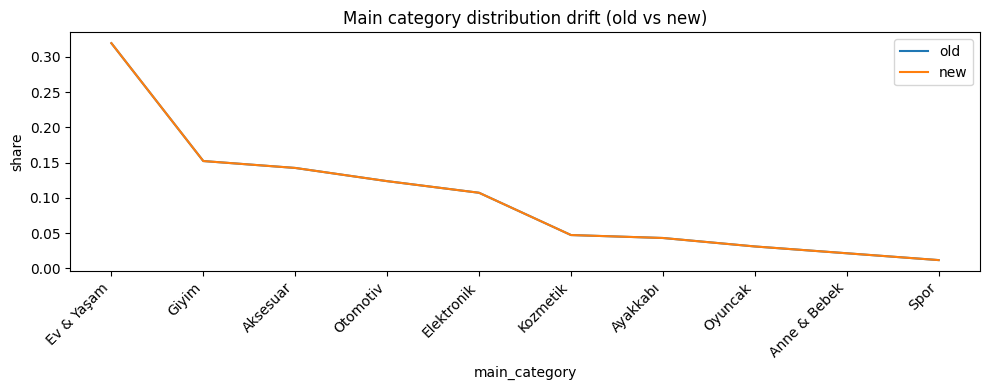

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) pick which category column is the "final" label ---
if "category_fixed" in LSH_df.columns:
    FIX_COL = "category_fixed"
else:
    FIX_COL = "category"

# --- 1) compute old vs new main_category using your mapping rule ---
# keep a copy of the previous one (even if it already exists)
LSH_df = LSH_df.copy()

LSH_df["main_category_old"] = LSH_df["category"].map(category_mapping).fillna("Diğer")

# apply your requested mapping code for the fixed categories
LSH_df["main_category"] = LSH_df[FIX_COL].map(category_mapping).fillna("Diğer")

# --- 2) drift report (old vs new main_category distribution) ---
old_cnt = LSH_df["main_category_old"].value_counts()
new_cnt = LSH_df["main_category"].value_counts()

cats = old_cnt.index.union(new_cnt.index)
old_p = (old_cnt.reindex(cats, fill_value=0) / old_cnt.sum()).values
new_p = (new_cnt.reindex(cats, fill_value=0) / new_cnt.sum()).values

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))

js = js_divergence(old_p, new_p)
print("JS divergence(main_category old vs new):", js)

drift_df = pd.DataFrame({
    "old_cnt": old_cnt.reindex(cats, fill_value=0),
    "new_cnt": new_cnt.reindex(cats, fill_value=0),
})
drift_df["old_pct"] = drift_df["old_cnt"] / drift_df["old_cnt"].sum()
drift_df["new_pct"] = drift_df["new_cnt"] / drift_df["new_cnt"].sum()
drift_df["delta_pct"] = drift_df["new_pct"] - drift_df["old_pct"]

drift_df = drift_df.sort_values("delta_pct", ascending=False)
display(drift_df)

# --- 3) simple plot: old vs new main_category share ---
plot_order = drift_df.index.tolist()
x = np.arange(len(plot_order))

plt.figure(figsize=(10,4))
plt.plot(drift_df.loc[plot_order, "old_pct"].values, label="old")
plt.plot(drift_df.loc[plot_order, "new_pct"].values, label="new")
plt.title("Main category distribution drift (old vs new)")
plt.xlabel("main_category"); plt.ylabel("share")
plt.xticks(x, plot_order, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


In [66]:
LSH_df

,product_id,product_text,category,product_text_clean,dominant_category,purity,total_cnt,canon_text,text_for_model,char_len,...,main_category,hash_text,fold2,mismatch_oof,pred_category_oof,gap_oof,margin_oof,flag_suspect,category_fixed,main_category_old
0,214477867,Lg K11 2.4a Hızlı Şarj Kablosu 2m Golden Serie...,Şarj Cihazı & Kablo,lg k11 2 4a hızlı şarj kablosu 2m golden serie...,Şarj Cihazı & Kablo,1.0,1.0,lg k11 2 4a hizli sarj kablosu 2m golden serie...,lg k11 2 4a hızlı şarj kablosu 2m golden serie...,80,...,Elektronik,lg k11 2 4a hızlı şarj kablosu 2m golden serie...,0,False,Şarj Cihazı & Kablo,0.0,11.618119,False,Şarj Cihazı & Kablo,Elektronik
1,104723304,Müthiş Satisfyer Dual Pleasure Telefon Kontrol...,Vibratör,müthiş satisfyer dual pleasure telefon kontrol...,Vibratör,1.0,1.0,muthis satisfyer dual pleasure telefon kontrol...,müthiş satisfyer dual pleasure telefon kontrol...,68,...,Kozmetik,müthiş satisfyer dual pleasure telefon kontrol...,0,False,Vibratör,0.0,9.573932,False,Vibratör,Kozmetik
2,134486860,Sıva Altı Dekoratif 12w Modül Led 3000k(GÜNIŞI...,Spot Lamba,sıva altı dekoratif 12w modül led 3000k günişi...,Spot Lamba,1.0,1.0,siva alti dekoratif 12w modul led 3000k gunisi...,sıva altı dekoratif 12w modül led 3000k günişi...,53,...,Ev & Yaşam,sıva altı dekoratif 12w modül led 3000k günişi...,0,False,Spot Lamba,0.0,2.324795,False,Spot Lamba,Ev & Yaşam
3,106247966,Pc Ekmek Kutusu,Ekmek Kutusu ve Sepetleri,pc ekmek kutusu,Ekmek Kutusu ve Sepetleri,1.0,1.0,pc ekmek kutusu,pc ekmek kutusu,15,...,Ev & Yaşam,pc ekmek kutusu,1,False,Ekmek Kutusu ve Sepetleri,0.0,4.250652,False,Ekmek Kutusu ve Sepetleri,Ev & Yaşam
4,117703257,3mm Philips 55pus6262 Uyumlu Tv Ekran Koruyucu...,TV Ekran Koruyucular,3mm philips 55pus6262 uyumlu tv ekran koruyucu...,TV Ekran Koruyucular,1.0,1.0,3mm philips 55pus6262 uyumlu tv ekran koruyucu...,3mm philips 55pus6262 uyumlu tv ekran koruyucu...,66,...,Elektronik,3mm philips 55pus6262 uyumlu tv ekran koruyucu...,1,False,TV Ekran Koruyucular,0.0,12.240839,False,TV Ekran Koruyucular,Elektronik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4664357,142496167,265/40zr20 104y Xl Acoustic M01 Pilot Sport 4s...,Lastik,265 40zr20 104y xl acoustic m01 pilot sport 4s...,Lastik,1.0,1.0,265 40zr20 104y xl acoustic m01 pilot sport 4s...,265 40zr20 104y xl acoustic m01 pilot sport 4s...,55,...,Otomotiv,265 40zr20 104y xl acoustic m01 pilot sport 4s...,1,False,Lastik,0.0,10.067330,False,Lastik,Otomotiv
4664358,213018596,Pure Oje: 609 Kategori: Oje,Oje,pure oje 609 kategori oje,Oje,1.0,1.0,pure oje 609 kategori oje,pure oje 609 kategori oje,25,...,Kozmetik,pure oje 609 kategori oje,1,False,Oje,0.0,15.807930,False,Oje,Kozmetik
4664359,205963428,Dekoratif Çok Amaçlı Mermer Kenarlıklı Tepsi B...,Tepsi,dekoratif çok amaçlı mermer kenarlıklı tepsi b...,Tepsi,1.0,1.0,dekoratif cok amacli mermer kenarlikli tepsi b...,dekoratif çok amaçlı mermer kenarlıklı tepsi b...,79,...,Ev & Yaşam,dekoratif çok amaçlı mermer kenarlıklı tepsi b...,0,False,Tepsi,0.0,4.731008,False,Tepsi,Ev & Yaşam
4664360,58894024,281 Et Ve Köfte Tutucu Izgara Mangal 63cm Krom...,Mangal Aksesuarları,281 et ve köfte tutucu izgara mangal 63cm krom...,Mangal Aksesuarları,1.0,1.0,281 et ve kofte tutucu izgara mangal 63cm krom...,281 et ve köfte tutucu izgara mangal 63cm krom...,54,...,Ev & Yaşam,281 et ve köfte tutucu izgara mangal 63cm krom...,1,False,Mangal Aksesuarları,0.0,0.949315,False,Mangal Aksesuarları,Ev & Yaşam


In [67]:
import re
import pandas as pd
import numpy as np

template_df = LSH_df.copy()

template_df["canon_text"] = template_df["canon_text"].fillna("").astype(str)
template_df["main_category"] = template_df["main_category"].fillna("").astype(str)

# Normalize common patterns so keys become consistent
t = template_df["canon_text"].str.lower()

# 3.5mm variants -> 3_5mm
t = t.str.replace(r"\b3\s*[.,]?\s*5\s*mm\b", " 3_5mm ", regex=True)

# 65 w -> 65w
t = t.str.replace(r"\b(\d+)\s*w\b", r"\1w", regex=True)

# 500 ml -> 500ml
t = t.str.replace(r"\b(\d+)\s*ml\b", r"\1ml", regex=True)

# unify whitespace
t = t.str.replace(r"\s+", " ", regex=True).str.strip()

template_df["canon_text"] = t


In [68]:
from tqdm.auto import tqdm
tqdm.pandas()

# --- Common token sets ---
COLORS = {
    "siyah","beyaz","mavi","kirmizi","yesil","gri","mor","pembe","turuncu","kahverengi","lacivert","bej","bordo",
    # ink/toner colors
    "sari","cyan","magenta","macenta","mavi","black","yellow"
}

MARKETING = {
    "orijinal","orjinal","muadil","premium","luxury","golden","series","sert","seffaf","desenli",
    "kampanya","indirim","firsat","ucretsiz","kargo","bedava","yeni","sezon","kaliteli"
}

GENERIC = {
    "icin","for","ve","ile","uyumlu","set","paket","takim","adet","parca","x","x2","x3","x4","x5"
}

# Keep these numeric tokens (we DROP most other numbers)
KEEP_NUM_PATTERNS = [
    re.compile(r"^\d+w$"),         # 65w
    re.compile(r"^\d+mah$"),       # 5000mah
    re.compile(r"^\d+w\d+$"),      # 5w30
    re.compile(r"^\d+ml$"),        # 500ml (sometimes useful)
    re.compile(r"^\d+cm$"),        # 90cm (rarely useful, but ok)
]

def keep_numeric_token(tok: str) -> bool:
    return any(p.match(tok) for p in KEEP_NUM_PATTERNS)

def is_numberish(tok: str) -> bool:
    # tokens with digits (11, 55pus6262, 20x30cm, etc.)
    return any(ch.isdigit() for ch in tok)

# --- Elektronik rules ---
ELEC_BRANDS = {"apple","samsung","lg","sony","huawei","philips","canon","epson","hp","lenovo","xiaomi","anker","jbl"}

ELEC_CONNECTORS = {"microusb","usb","typec","lightning","bluetooth","3_5mm"}

ELEC_PRODUCT_RULES = [
    ({"sarj","kablosu"}, "sarj kablosu"),
    ({"ekran","koruyucu"}, "ekran koruyucu"),
    ({"kulaklik"}, "kulaklik"),
    ({"hoparlor"}, "hoparlor"),
    ({"adaptor"}, "adaptor"),
    ({"sarj","aleti"}, "adaptor"),
    ({"toner"}, "toner"),
    ({"kartus"}, "kartus"),
    ({"murekkep"}, "murekkep"),
    ({"fm","transmitter"}, "fm transmitter"),
    ({"uydu","alici"}, "uydu alici"),
    ({"kilif"}, "kilif"),
    ({"fan"}, "fan"),
    ({"telefontutucu"}, "telefontutucu"),
    ({"stand"}, "stand"),
]

# --- Ev & Yaşam rules ---
HOME_PRODUCT_RULES = [
    ({"modul","led","spot"}, "led spot"),
    ({"led","spot"}, "led spot"),
    ({"ekmek","kutusu"}, "ekmek kutusu"),
    ({"fide"}, "fide"),
    ({"tohum"}, "tohum"),
    ({"kahvesi"}, "kahve"),
    ({"kahve"}, "kahve"),
    ({"silgi"}, "silgi"),
    ({"kesim","panosu"}, "kesim panosu"),
    ({"buhurdanlik"}, "buhurdanlik"),
    ({"neon","led"}, "neon led"),
    ({"oda","kokusu"}, "oda kokusu"),
    ({"hava","ferahlatici"}, "oda kokusu"),
    ({"kupa"}, "kupa"),
    ({"cirpici"}, "cirpici"),
    ({"biblo"}, "biblo"),
    ({"halisi"}, "makine halisi"),
    ({"aparat"}, "aparat"),
    ({"yapay","dali"}, "yapay cicek dali"),
    ({"yapay"}, "yapay urun"),
]

# --- Other main categories: lightweight “type-first” fallback keywords ---
FALLBACK_TYPE_TOKENS = {
    "Giyim": ["tisort","gomlek","pantolon","elbise","etek","sweatshirt","kaban","mont","kazak","sort","tayt"],
    "Kozmetik": ["krem","serum","sampuan","ruj","maskara","fondoten","gunes","spf","deodorant","parfum","lotion"],
    "Aksesuar": ["kolye","kupe","bileklik","yuzuk","canta","cuzdan","saat","gozluk","kilif"],
    "Anne & Bebek": ["bebek","bez","mama","biberon","emzik","islak","mendil","oyuncak"],
    "Oyuncak": ["puzzle","lego","oyuncak","bebek","araba","slime","zeka","akil"],
    "Spor": ["dambil","mat","yoga","eldiven","top","forma","kosu","dizlik","halter"],
    "Ayakkabı": ["ayakkabi","terlik","bot","topuklu","sneaker","spor","yuruyus","kosu"],
    "Otomotiv": ["motor","yagi","silecek","jant","kapagi","fren","balata","filtre","aku","tampon","stop","bagaj","paspas","lip"],
}

def detect_product_type(tokens_set, rules):
    for req, name in rules:
        if req.issubset(tokens_set):
            return name
    return ""

def pick_brand(tokens):
    for tok in tokens:
        if tok in ELEC_BRANDS:
            return tok
    return ""

def extract_ink_color(tokens):
    for tok in tokens:
        if tok in COLORS:
            return tok
    return ""

def build_template_key(main_cat: str, text: str) -> str:
    # Tokenize
    toks = text.split()
    if not toks:
        return ""

    toks_set = set(toks)

    # Base filtering: drop marketing/generic; drop most numberish tokens
    filtered = []
    for tok in toks:
        if tok in MARKETING or tok in GENERIC:
            continue

        if is_numberish(tok) and not keep_numeric_token(tok):
            # drop model codes, sizes, etc. by default
            continue

        if tok in COLORS:
            # generally drop colors; we add back selectively for ink/toner
            continue

        filtered.append(tok)

    filtered_set = set(filtered)

    # Category-specific logic
    if main_cat == "Elektronik":
        brand = pick_brand(filtered)

        ptype = detect_product_type(filtered_set, ELEC_PRODUCT_RULES)
        if not ptype:
            # fallback: try to keep a short stable key
            ptype = " ".join(filtered[:2]) if len(filtered) >= 2 else (filtered[0] if filtered else "")

        parts = []
        if brand:
            parts.append(brand)
        parts.append(ptype)

        # connectors (helpful, stable)
        conns = [c for c in ELEC_CONNECTORS if c in filtered_set]
        conns.sort()
        parts.extend(conns[:2])

        # wattage (helpful for adaptor)
        if "adaptor" in ptype or "sarj" in ptype:
            w = [tok for tok in filtered if re.match(r"^\d+w$", tok)]
            if w:
                parts.append(w[0])

        # ink/toner colors (very meaningful)
        if any(x in ptype for x in ["kartus","murekkep","toner"]):
            col = extract_ink_color(toks)  # use original tokens to catch dropped colors
            if col:
                parts.append(col)

        return " ".join(parts).strip()

    if main_cat == "Ev & Yaşam":
        ptype = detect_product_type(filtered_set, HOME_PRODUCT_RULES)
        if not ptype:
            # fallback: keep first 2–3 informative tokens
            ptype = " ".join(filtered[:3]) if len(filtered) >= 3 else " ".join(filtered[:2])

        # add one material token if present (optional but helps grouping)
        material = ""
        for m in ["cam","seramik","silikon","metal","plastik","ahsap","celik","porselen"]:
            if m in filtered_set:
                material = m
                break

        parts = [ptype]
        if material and material not in ptype:
            parts.append(material)

        return " ".join(parts).strip()

    # Fallback for other main categories: pick first matching type token
    key_types = FALLBACK_TYPE_TOKENS.get(main_cat, [])
    found = ""
    for tt in key_types:
        if tt in filtered_set:
            found = tt
            break

    if not found:
        # fallback: first 2 tokens after filtering
        return " ".join(filtered[:2]).strip()

    # add one optional stabilizer token (e.g., "kadin/erkek" for giyim/ayakkabı)
    stabilizers = []
    if main_cat in {"Giyim","Ayakkabı"}:
        for s in ["kadin","erkek","cocuk","bebek"]:
            if s in filtered_set:
                stabilizers.append(s)
                break

    return " ".join(stabilizers + [found]).strip()


# Build template_key with a progress bar
template_df["template_key"] = template_df.progress_apply(lambda r: build_template_key(r["main_category"], r["canon_text"]), axis=1)

template_df[["main_category", "canon_text", "template_key"]].head(20)


100%|██████████| 4664362/4664362 [02:17<00:00, 33917.30it/s]


,main_category,canon_text,template_key
0,Elektronik,lg k11 2 4a hizli sarj kablosu 2m golden serie...,lg sarj kablosu microusb
1,Kozmetik,muthis satisfyer dual pleasure telefon kontrol...,muthis satisfyer
2,Ev & Yaşam,siva alti dekoratif 12w modul led 3000k gunisi...,led spot
3,Ev & Yaşam,pc ekmek kutusu,ekmek kutusu
4,Elektronik,3mm philips 55pus6262 uyumlu tv ekran koruyucu...,philips ekran koruyucu
5,Ev & Yaşam,cilek fidesi x40 yediveren cilek fidesi cilek ...,fide
6,Ev & Yaşam,yapay lux ortanca dali 90cm somon kahve,kahve
7,Ev & Yaşam,sutlu menengic kahvesi x5,kahve
8,Ev & Yaşam,n20 noris silgi,silgi
9,Aksesuar,6214 twill ipek esarp,twill ipek


In [69]:
topk = (template_df.groupby(["main_category", "template_key"])
          .size()
          .reset_index(name="cnt")
          .sort_values(["main_category", "cnt"], ascending=[True, False]))

display(topk.groupby("main_category").head(15))


,main_category,template_key,cnt
56682,Aksesuar,kolye,73284
58643,Aksesuar,kupe,66962
11216,Aksesuar,bileklik,57909
110115,Aksesuar,yuzuk,38931
15574,Aksesuar,canta,27895
...,...,...,...
1079690,Spor,germe ip,159
1091631,Spor,whey protein,154
1090099,Spor,tide minnow,151
1087444,Spor,sahte balik,133


In [70]:
import numpy as np
import pandas as pd

TEXT_COL = "canon_text"
MAIN_COL = "main_category"
LABEL_COL = "category"      # your fine-grained label
KEY_COL = "template_key"    # your current key

df = template_df.copy()
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[MAIN_COL] = df[MAIN_COL].fillna("").astype(str)
df[KEY_COL]  = df[KEY_COL].fillna("").astype(str)
df[LABEL_COL]= df[LABEL_COL].fillna("").astype(str)

# 1) Find "too-big" keys per main_category (refine only these)
COARSE_THRESH = 30_000  # tune: 10k/30k/50k
key_cnt = df.groupby([MAIN_COL, KEY_COL]).size().rename("cnt").reset_index()

df = df.merge(key_cnt, on=[MAIN_COL, KEY_COL], how="left")
df["is_coarse"] = df["cnt"] >= COARSE_THRESH

# 2) Descriptor token extraction per main_category (fast regex)
# Pick one extra token to split big families (material/style/spec/connectors)
rx_aksesuar = r"\b(925|gumus|altin|celik|deri|inci|zirkon|tasli|pirlanta|pandora|charms|kisiye|ozel|isimli)\b"
rx_elektronik = r"\b(microusb|typec|lightning|bluetooth|3_5mm|\d+w|\d+mah|toner|kartus|murekkep|uydu|transmitter)\b"
rx_ev = r"\b(bambu|seramik|cam|metal|plastik|silikon|ahsap|porselen|led|neon|kupa|kahve|tohum|fide|hali|buhurdanlik|oda)\b"
rx_spor = r"\b(whey|protein|kreatin|dambil|halter|yoga|mat|eldiven|kosu|dizlik|olta|minnow|sahte|balik)\b"
rx_giyim = r"\b(pamuk|keten|denim|viskon|yün|yun|oversize|slim|regular)\b"
rx_ayakkabi = r"\b(deri|suet|ortopedik|kadin|erkek|cocuk|bebek)\b"
rx_otomotiv = r"\b(5w30|5w40|10w40|silecek|jant|stop|bagaj|paspas|tampon|filtre|aku)\b"
rx_anne = r"\b(bebek|bez|islak|mendil|mama|biberon|emzik)\b"
rx_oyuncak = r"\b(puzzle|lego|disney|marvel|pokemon|bebek|araba|zeka|akil)\b"
rx_kozmetik = r"\b(spf|gunes|retinol|niacinamide|hyaluronik|serum|krem|sampuan|parfum)\b"

df["desc_token"] = ""

m = df[MAIN_COL].eq("Aksesuar")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_aksesuar, expand=False).fillna("")

m = df[MAIN_COL].eq("Elektronik")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_elektronik, expand=False).fillna("")

m = df[MAIN_COL].eq("Ev & Yaşam")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_ev, expand=False).fillna("")

m = df[MAIN_COL].eq("Spor")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_spor, expand=False).fillna("")

m = df[MAIN_COL].eq("Giyim")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_giyim, expand=False).fillna("")

m = df[MAIN_COL].eq("Ayakkabı")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_ayakkabi, expand=False).fillna("")

m = df[MAIN_COL].eq("Otomotiv")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_otomotiv, expand=False).fillna("")

m = df[MAIN_COL].eq("Anne & Bebek")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_anne, expand=False).fillna("")

m = df[MAIN_COL].eq("Oyuncak")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_oyuncak, expand=False).fillna("")

m = df[MAIN_COL].eq("Kozmetik")
df.loc[m, "desc_token"] = df.loc[m, TEXT_COL].str.extract(rx_kozmetik, expand=False).fillna("")

# 3) Refine ONLY coarse keys; keep others unchanged
df["template_key_ref"] = df[KEY_COL]
mask_ref = df["is_coarse"] & df["desc_token"].ne("")
df.loc[mask_ref, "template_key_ref"] = df.loc[mask_ref, KEY_COL] + " " + df.loc[mask_ref, "desc_token"]

# sanity: show how much coarse keys got split
print("Coarse rows:", int(df["is_coarse"].sum()))
df[[MAIN_COL, KEY_COL, "desc_token", "template_key_ref", "cnt"]].head(10)


Coarse rows: 451279


,main_category,template_key,desc_token,template_key_ref,cnt
0,Elektronik,lg sarj kablosu microusb,microusb,lg sarj kablosu microusb,68
1,Kozmetik,muthis satisfyer,,muthis satisfyer,1
2,Ev & Yaşam,led spot,led,led spot,877
3,Ev & Yaşam,ekmek kutusu,,ekmek kutusu,129
4,Elektronik,philips ekran koruyucu,,philips ekran koruyucu,946
5,Ev & Yaşam,fide,fide,fide,490
6,Ev & Yaşam,kahve,kahve,kahve,28860
7,Ev & Yaşam,kahve,,kahve,28860
8,Ev & Yaşam,silgi,,silgi,1885
9,Aksesuar,twill ipek,,twill ipek,1163


In [71]:
# ---- cap config ----
CAP_MAX = 1200        # max samples per (category, template_key_ref)
SEED = 42

# shuffle order cheaply (avoid df.sample(frac=1) on huge data)
rng = np.random.RandomState(SEED)
order = rng.permutation(len(df))
df_shuf = df.iloc[order].copy()

grp = [LABEL_COL, "template_key_ref"]

# group sizes + within-group rank
df_shuf["gsize"] = df_shuf.groupby(grp)[TEXT_COL].transform("size")
df_shuf["grank"] = df_shuf.groupby(grp).cumcount()

# keep all if small; otherwise cap
df_reduced = df_shuf[df_shuf["grank"] < CAP_MAX].copy()

print("Before:", len(df))
print("After :", len(df_reduced))
print("Reduction %:", round(100 * (1 - len(df_reduced)/len(df)), 2))


Before: 4664362
After : 3783477
Reduction %: 18.89


In [72]:
import numpy as np
import pandas as pd

df = df_reduced.copy()
# clean up helper cols if you re-ran cells
for c in ["gsize", "cap_key", "rank_key", "cat_cnt", "cap_cat", "rank_cat"]:
    if c in df.columns:
        df.drop(columns=c, inplace=True, errors="ignore")

LABEL_COL = "category"
KEY_COL   = "template_key_ref"
TEXT_COL  = "canon_text"

# Basic filters (optional but recommended)
df = df[df[TEXT_COL].fillna("").astype(str).str.len() >= 5].copy()

# -----------------------------
# 1) Per-category cap (head reduction)
# -----------------------------
cat_cnt = df.groupby(LABEL_COL).size().rename("cat_cnt")
df = df.join(cat_cnt, on=LABEL_COL)

# Choose caps that match your compute goal
# Tune these 3 numbers to land around 300k–1M
CAP_SMALL = 999999999  # keep all if <= THR_SMALL
THR_SMALL = 5_000

CAP_MED   = 12_000      # cap if between THR_SMALL and THR_BIG
THR_BIG   = 20_000

CAP_BIG   = 8_000       # cap if >= THR_BIG

df["cap_cat"] = np.where(df["cat_cnt"] <= THR_SMALL, CAP_SMALL,
                  np.where(df["cat_cnt"] <  THR_BIG,  CAP_MED, CAP_BIG)).astype(int)

# Shuffle once (cheap & reproducible)
rng = np.random.RandomState(42)
df = df.iloc[rng.permutation(len(df))].copy()

# Keep up to cap per category
df["rank_cat"] = df.groupby(LABEL_COL).cumcount()
df1 = df[df["rank_cat"] < df["cap_cat"]].copy()

print("After per-category cap:", len(df1))

# -----------------------------
# 2) Per (category, template_key_ref) cap (template repetition reduction)
# -----------------------------
# Dynamic cap: very large template blocks get a small cap, small blocks keep all
grp = [LABEL_COL, KEY_COL]
gsize = df1.groupby(grp).size().rename("gsize")
df1 = df1.join(gsize, on=grp)

# Caps by template-block size
# If a (category, key) block has 50k rows, keeping 200 is usually enough.
df1["cap_key"] = np.where(df1["gsize"] >= 5000, 200,
                   np.where(df1["gsize"] >= 1000, 400,
                   np.where(df1["gsize"] >= 300,  800, 999999999))).astype(int)

df1["rank_key"] = df1.groupby(grp).cumcount()
df_final = df1[df1["rank_key"] < df1["cap_key"]].copy()

print("Final rows:", len(df_final))
print("Categories kept:", df_final[LABEL_COL].nunique(), "/", df[LABEL_COL].nunique())


After per-category cap: 3076362
Final rows: 2872653
Categories kept: 1140 / 1140


In [175]:
df_final.to_csv("preprocessed_train.csv", index=False)

In [74]:
df_final.to_csv("preprocessed_train_final.csv", index=False)
LSH_df.to_csv("preprocessed_train_LSH.csv", index=False)

In [108]:
import numpy as np
import pandas as pd

test = canon_df_test.copy()

# 1) apply same cleaning functions you used in train
# (replace these with YOUR actual functions/columns used in EDA.ipynb)
test["product_text_clean"] = (
    test["product_text"].fillna("").astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# If you already have a canonize_series() function from earlier, use it:
# test["canon_text"] = canonize_series(test["product_text_clean"])

# Otherwise, if your canonicalization already exists as an applied step in train code,
# copy/paste the same logic here. Placeholder:
test["canon_text"] = test["product_text_clean"]  # <-- REPLACE with your canonicalization pipeline

# hash_text (used for fast classifier; light clean, punctuation->space)
test["hash_text"] = (test["product_text_clean"]
    .str.replace(r"[^\w\sğüşöçıİĞÜŞÖÇ]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 2) junk flags (do NOT drop in test; just flag)
test["tok_cnt"]  = test["hash_text"].str.split().str.len()
test["char_len"] = test["hash_text"].str.len()
test["is_junk"]  = (test["tok_cnt"] < 2) | (test["char_len"] < 5)

print("Test rows:", len(test))
print("Junk rate:", test["is_junk"].mean())

# 3) exact duplicate stats in test
dup_rate = test["canon_text"].duplicated().mean()
print("Exact duplicate rate in test (canon_text):", dup_rate)

# optional: table of top duplicated canon_texts
dup_counts = test["canon_text"].value_counts()
display(dup_counts.head(20))


Test rows: 1082903
Junk rate: 0.0
Exact duplicate rate in test (canon_text): 0.0


canon_text
40507 ortopedik günlük erkek terlik                                                               1
kadın beyaz 3 çift pamuklu bilek boyu çorap                                                       1
fırsat ayı krom 5 katlı pantolon eşarp askısı ( 24 adet )                                         1
wear tatlı teriyer gri kadın eşofman altı                                                         1
antik gümüş kaplama yüzük set sty0064                                                             1
erkek kol saati 124231                                                                            1
2li krem zeminde pembe çiçek tukuaz dal desne yuvarlak amerikan servisi supla & servis altlığı    1
bebek kolay tarama şampuanı 700 ml                                                                1
100x150 mor yildiz kişiye özel çocuk odasi halisi                                                 1
gt135 arka fren merkez komple orjinal                                                    

In [109]:
# Build canon set from train
if "canon_text" not in LSH_df.columns:
    raise ValueError("LSH_df needs canon_text for leakage checks.")

train_canon_set = set(LSH_df["canon_text"].astype(str).values)

test["is_exact_leak"] = test["canon_text"].astype(str).isin(train_canon_set)
print("Exact leakage rate test->train:", test["is_exact_leak"].mean())

# Optional: if you have train cluster_id, attach for exact leaks
if "cluster_id" in LSH_df.columns:
    canon2cluster = (LSH_df[["canon_text","cluster_id"]]
                     .drop_duplicates("canon_text")
                     .set_index("canon_text")["cluster_id"])
    test["train_cluster_id_if_exact"] = test["canon_text"].map(canon2cluster)


Exact leakage rate test->train: 0.0


In [110]:
unique_test = test.drop_duplicates("canon_text").copy()
print("Unique canon_text in test:", len(unique_test), "vs total:", len(test))
# run model on unique_test, then merge predictions back by canon_text


Unique canon_text in test: 1082903 vs total: 1082903


In [111]:
unique_test.to_csv("preprocessed_test_final.csv", index=False)
